<a href="https://colab.research.google.com/github/Konstantinosil/Chortareas-Linardatos-A-Macro-Augmented-Jump-Diffusion-Shadow-Rate-Model/blob/main/Central_Bank_Credibility_after_the_Global_Financial_Crisis_Evidence_from_Rule_Based_and_Shadow_Rate_Approaches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Figure 1. First Credibility Score


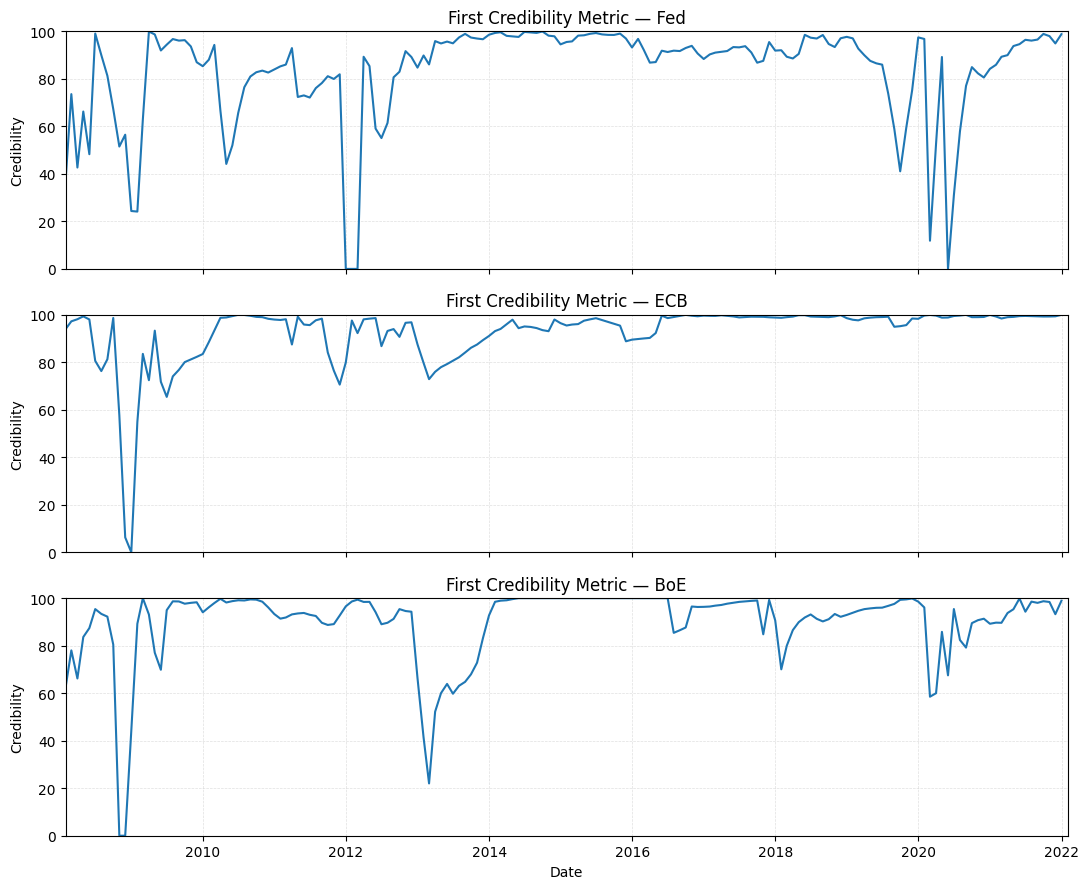


AP(3) DETERMINANTS — RAW LOW-CREDIBILITY
LHS: AP3_raw_lowcred
Interpretation: larger LHS = lower credibility.

------------------------------------------------------------------------------
H1A — Outcome-based p-share: pooled + ELB interaction
------------------------------------------------------------------------------

[H1A pooled: NO interaction]
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3567      0.137      2.599      0.009       0.088       0.626
p_share_F           -0.1237      0.131     -0.947      0.343      -0.380       0.132
ELB                  0.1842      0.083      2.216      0.027       0.021       0.347
QE_FG               -0.2527      0.089     -2.838      0.005      -0.427      -0.078
crisis10            -0.0457      0.056     -0.815      0.415      -0.155       0.064
pandem              -0.0338      0.030     -1.109  

,window,mse,n_surprise
0,60,0.040842,636
1,72,0.043874,636
2,84,0.047148,636
3,36,0.049479,636
4,48,0.078933,636



US 5y5y validation: correlations


,label,corr_y_t5y5y_pearson,corr_y_t5y5y_spearman,corr_y_absdev_pearson,corr_y_absdev_spearman
0,AP(3) raw low-credibility,-0.562049,-0.580427,0.297931,-0.043945



US 5y5y validation: regression


,spec,variable,coef,se_hac,t_hac,p_hac,ci_low,ci_high
0,US_validation_AP(3) raw low-credibility,abs_anch_dev,0.647711,0.237667,2.725292,0.006424,0.181893,1.113528



US 5y5y validation: summary


,label,higher_is_worse,beta_abs_anch_dev,se_hac,p_hac,n_joint,sample_start,sample_end
0,AP(3) raw low-credibility,True,0.647711,0.237667,0.006424,96,2014-01-31,2021-12-31


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.3 MB/s eta 0:00:00

WU & XIA PIPELINE (FULL)

=== Data coverage (non-missing counts) ===
SR {'EU': np.int64(169), 'UK': np.int64(169), 'US': np.int64(169)}
INF {'EU': np.int64(169), 'UK': np.int64(169), 'US': np.int64(169)}
GDP {'EU': np.int64(169), 'UK': np.int64(169), 'US': np.int64(169)}



=== EGARCH meta (baseline SR-level) ===
   ar_lags egarch_ok
US       0      True
EU       0      True
UK       0      True

=== Anchor stats (pooled scaling) ===
{'q_lo': -1.9768540176810874, 'q_hi': 1.0508624963717477, 'anchor_end': '2010-12-01'}


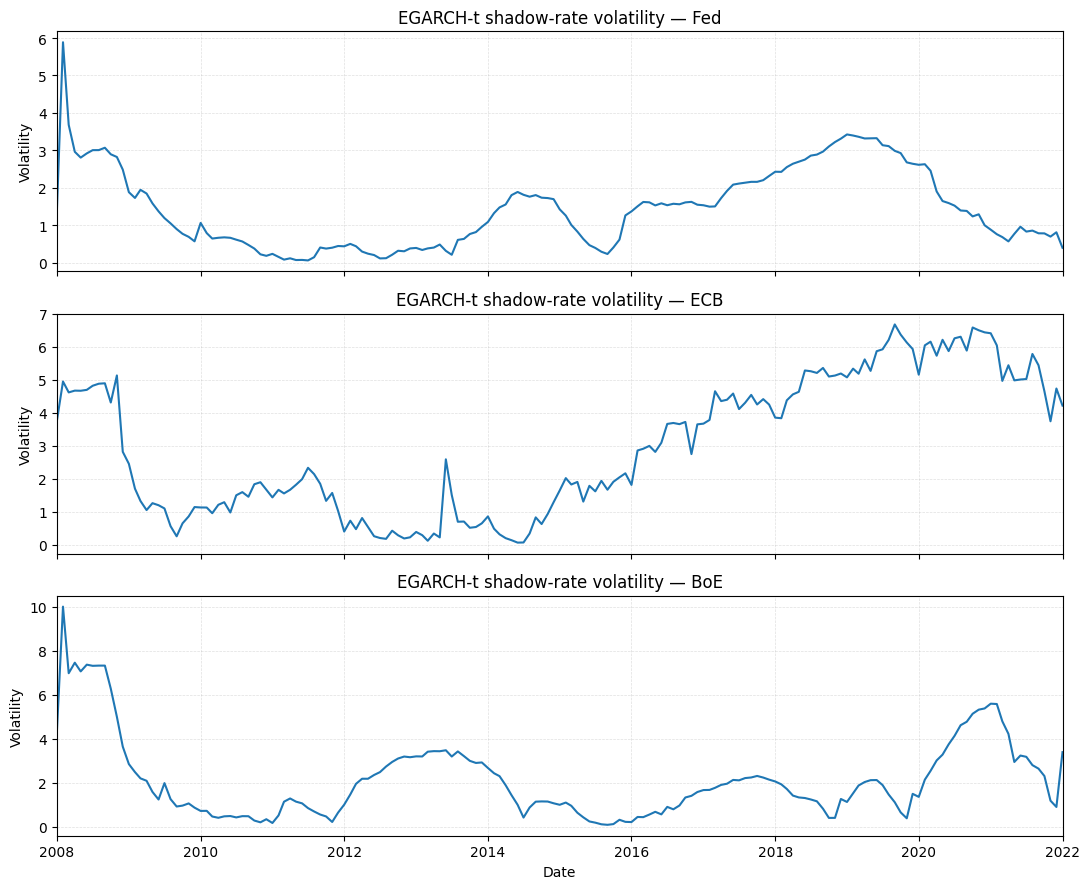

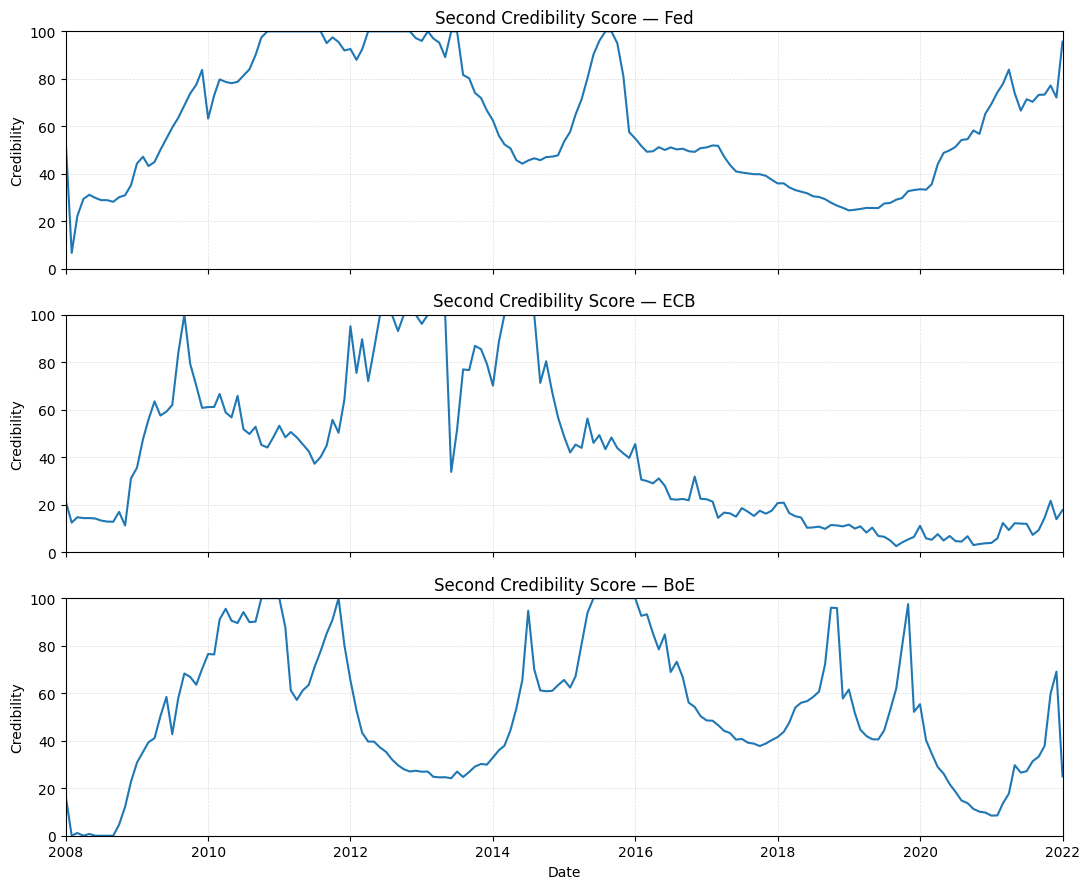


=== Robustness: baseline EGARCH credibility vs GJR-GARCH credibility ===
econ  corr(egarch,gjr)  T_common
  US          0.989707       169
  EU          0.973072       169
  UK          0.991215       169
Pooled corr(egarch,gjr) = 0.984 (N=507)

=== GJR meta ===
   ar_lags gjr_ok
US       0   True
EU       0   True
UK       0   True

==================== SACRIFICE RATIO REGRESSION (WX only) ====================
(Estimation sample restricted to date >= 2008-01-01)
Model: SR_H12 ~ const + cred(t-12) + country dummies (pooled)
Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.

[Baseline cred = EGARCH]  HAC:  b=-0.0094, se=0.0030, p=0.0017 | N=169 | maxlags=12

--- EGARCH credibility regression table (HAC) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8792      0.254      3.462      0.001       0.382       1.377
cred_lag12

In [1]:

from __future__ import annotations

import logging
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

try:
    from IPython.display import display
    from IPython import get_ipython
except Exception:
    get_ipython = None

    def display(obj):
        print(obj)


def _activate_inline_backend():
    ip = get_ipython() if callable(get_ipython) else None
    if ip is not None:
        try:
            ip.run_line_magic("matplotlib", "inline")
        except Exception:
            pass


_activate_inline_backend()

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")


@dataclass(frozen=True)
class JournalConfig:
    ROOT_LOCAL: str = "."
    MAIN_FILE: str = "just for the AP.xlsx"
    SUPPORT_FILE: str = "supportive.xlsx"
    REPORTED_START: str = "2008-01-01"
    END: str = "2022-01-31"
    AP_PRESAMPLE_START: str = "2000-01-01"
    PI_STAR: float = 2.0
    HAC_LAGS_BASE: int = 6
    ELB_EPS: float = 0.10
    ELB_THRESHOLDS: Optional[Dict[str, float]] = None
    RF_WINDOW_CAND: Tuple[int, ...] = (36, 48, 60, 72, 84)
    AP_SCALE_P_LO: int = 1
    AP_SCALE_P_HI: int = 99
    RUN_ADF: bool = False
    WILD_BOOT_B: int = 399
    SEED: int = 123
    SAVE_FIGURES: bool = False
    WRITE_RESULTS_TO_FILES: bool = False

    def __post_init__(self):
        if self.ELB_THRESHOLDS is None:
            object.__setattr__(
                self,
                "ELB_THRESHOLDS",
                {"ECB": 0.10, "BoE": 0.25, "Fed": 0.25},
            )


CFG = JournalConfig()

BANK_CODE_TO_NAME = {"EU": "ECB", "UK": "BoE", "US": "Fed"}
BANK_NAME_TO_CODE = {v: k for k, v in BANK_CODE_TO_NAME.items()}
BANK_ORDER = ["Fed", "ECB", "BoE"]

def set_seeds(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)

def resolve_input_file(filename: str, root_local: Optional[str] = None) -> Path:
    candidates = []
    if root_local:
        candidates.append(Path(root_local) / filename)
    candidates.extend(
        [
            Path.cwd() / filename,
            Path("/content") / filename,
            Path("/mnt/data") / filename,
            Path(filename),
        ]
    )

    seen = set()
    unique = []
    for p in candidates:
        key = str(p.resolve()) if p.exists() else str(p)
        if key not in seen:
            seen.add(key)
            unique.append(p)

    for p in unique:
        if p.exists():
            return p

    searched = "\n".join(str(x) for x in unique)
    raise FileNotFoundError(f"Could not find '{filename}'. Searched:\n{searched}")


def show_heading(title: str):
    bar = "=" * max(44, len(title))
    print(f"\n{bar}\n{title}\n{bar}")


def show_table(title: str, obj, max_rows: int = 200):
    show_heading(title)
    if obj is None:
        print("(none)")
        return
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    if not hasattr(obj, "__len__") or len(obj) == 0:
        print("(empty)")
        return
    try:
        display(obj if len(obj) <= max_rows else obj.head(max_rows))
        if len(obj) > max_rows:
            print(f"Displayed first {max_rows} rows out of {len(obj)}.")
    except Exception:
        print(obj if len(obj) <= max_rows else obj.head(max_rows))


def save_fig(fig: plt.Figure, save_path: Optional[Path] = None, save_flag: bool = False):
    if save_flag and save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def winsorize_df(df: pd.DataFrame, cols: Sequence[str], p: float = 0.01) -> pd.DataFrame:
    z = df.copy()
    for c in cols:
        if c in z.columns and z[c].notna().any():
            lo, hi = z[c].quantile([p, 1 - p])
            z[c] = z[c].clip(lo, hi)
    return z


def params_as_series(res) -> pd.Series:
    return pd.Series(res.params, index=res.model.exog_names).astype(float)


def bse_as_series(res) -> pd.Series:
    return pd.Series(res.bse, index=res.model.exog_names).astype(float)


def pvalues_as_series(res) -> pd.Series:
    return pd.Series(res.pvalues, index=res.model.exog_names).astype(float)


def safe_get_triplet(res, var: str) -> Tuple[float, float, float]:
    return (
        float(params_as_series(res).get(var, np.nan)),
        float(bse_as_series(res).get(var, np.nan)),
        float(pvalues_as_series(res).get(var, np.nan)),
    )


def merge_no_overlap(
    left: pd.DataFrame,
    right: pd.DataFrame,
    on: Sequence[str],
    suffix: str = "_r",
    how: str = "left",
    validate: Optional[str] = None,
) -> pd.DataFrame:
    on = list(on)
    overlap = (set(left.columns) & set(right.columns)) - set(on)
    r = right.rename(columns={c: f"{c}{suffix}" for c in overlap})
    return left.merge(r, on=on, how=how, validate=validate)


def q25(x):
    return x.quantile(0.25)


def q75(x):
    return x.quantile(0.75)


def month_end(ts) -> pd.Timestamp:
    return (
        pd.Timestamp(ts).to_period("M").to_timestamp(how="start") + pd.offsets.MonthEnd(0)
    ).normalize()


def month_start(ts) -> pd.Timestamp:
    return pd.Timestamp(ts).to_period("M").to_timestamp(how="start")


def scale_series_to_0_100(
    s: pd.Series,
    p_lo: int = 1,
    p_hi: int = 99,
) -> Tuple[pd.Series, Dict[str, float]]:
    x = pd.to_numeric(pd.Series(s), errors="coerce")
    base = x.dropna()
    if base.empty:
        out = pd.Series(np.nan, index=x.index, dtype=float)
        return out, {"q_lo": np.nan, "q_hi": np.nan}

    q_lo = float(np.nanpercentile(base.values, p_lo))
    q_hi = float(np.nanpercentile(base.values, p_hi))
    width = max(1e-8, q_hi - q_lo)
    scaled = ((x - q_lo) / width * 100.0).clip(0, 100)

    return scaled.astype(float), {"q_lo": q_lo, "q_hi": q_hi}

def freq_audit(xls_path: Union[str, Path]) -> pd.DataFrame:
    xls = pd.ExcelFile(str(xls_path))
    rows = []
    for sh in xls.sheet_names:
        d = pd.read_excel(xls, sheet_name=sh)
        date_col = d.columns[0]
        dd = pd.to_datetime(d[date_col], errors="coerce").dropna().sort_values()
        try:
            freq = pd.infer_freq(dd[:10]) if len(dd) >= 10 else None
        except Exception:
            freq = None
        rows.append(
            {
                "sheet": sh,
                "n": int(len(dd)),
                "infer_freq": freq,
                "start": dd.min(),
                "end": dd.max(),
            }
        )
    return pd.DataFrame(rows)


def parse_main_sheet(name: str) -> Tuple[Optional[str], Optional[str]]:
    s = name.strip()
    parts = s.split()
    econ_code = parts[-1].upper()
    head = " ".join(parts[:-1]).lower()

    key = {
        "shadow rates": "SR",
        "policy rates": "POLICY",
        "inflation": "INF",
        "composite leader indicator": "CLI",
    }
    for k, v in key.items():
        if k in head:
            return v, econ_code

    if head.startswith("rgdp"):
        return "GDP", econ_code
    return None, None


def read_raw_sheet(path: Union[str, Path], sheet_name: str) -> pd.DataFrame:
    d = pd.read_excel(str(path), sheet_name=sheet_name)
    d = d.iloc[:, :2].copy()
    d.columns = ["date", "value"]
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

    raw = d["value"]
    num = pd.to_numeric(raw, errors="coerce")
    if num.notna().mean() < 0.5:
        num = (
            raw.astype(str)
            .str.replace("%", "", regex=False)
            .str.replace("\u2212", "-", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        num = pd.to_numeric(num, errors="coerce")

    d["value"] = num
    d = d.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    return d


def load_main_raw(path: Union[str, Path]) -> Dict[Tuple[str, str], pd.DataFrame]:
    xls = pd.ExcelFile(str(path))
    out: Dict[Tuple[str, str], pd.DataFrame] = {}
    for sh in xls.sheet_names:
        var, econ = parse_main_sheet(sh)
        if var is None or econ not in BANK_CODE_TO_NAME:
            continue
        out[(econ, var)] = read_raw_sheet(path, sh)
    return out

def infer_yoy_from_INF(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    return s.pct_change(12, fill_method=None) * 100.0 if (np.isfinite(med) and med > 30) else s


def to_monthly_eom_ch4(s: pd.Series, interpolate_quarterly: bool = True) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~pd.isna(s.index)]
    s = s.sort_index()

    if s.index.has_duplicates:
        s = s.groupby(level=0).last()

    inferred = (pd.infer_freq(s.index[:10]) or "").upper() if len(s) >= 3 else ""

    if inferred.startswith(("D", "B")):
        s = s.resample("ME").last()
        if s.index.has_duplicates:
            s = s.groupby(level=0).last()
        return s

    if inferred.startswith("Q"):
        q = s.copy()
        q.index = q.index.to_period("Q").to_timestamp("Q")
        q = q[~q.index.duplicated(keep="last")].sort_index()
        if not interpolate_quarterly:
            return q.resample("ME").last()

        monthly_idx = pd.date_range(
            q.index.min().to_period("M").to_timestamp("M"),
            q.index.max().to_period("M").to_timestamp("M"),
            freq="ME",
        )
        q_month = q.reindex(monthly_idx)
        q_month.loc[q.index] = q.values
        return q_month.interpolate(method="linear", limit_direction="both")

    if not s.index.is_month_end.all():
        s.index = s.index.to_period("M").to_timestamp("M")
    s = s.groupby(level=0).last().sort_index()
    return s.asfreq("ME")


def hamilton_output_gap(log_gdp: pd.Series, k: int = 12) -> pd.Series:
    y = pd.to_numeric(log_gdp, errors="coerce")
    Xlags = pd.concat([y.shift(i) for i in range(1, k + 1)], axis=1)
    Xlags.columns = [f"lag{i}" for i in range(1, k + 1)]

    resid = pd.Series(index=y.index, dtype=float)
    for t in range(k + 8, len(y)):
        X_t = sm.add_constant(Xlags.iloc[:t].dropna())
        idx = X_t.index
        y_t = y.loc[idx]
        if len(y_t) >= k + 5:
            beta = sm.OLS(y_t, X_t).fit().params
            row = sm.add_constant(Xlags.iloc[t : t + 1]).iloc[0]
            y_hat = float((row * beta.reindex(row.index).fillna(0)).sum())
            resid.iloc[t] = y.iloc[t] - y_hat
    return resid * 100.0

def build_chapter4_backbone(
    xls_path: Union[str, Path],
    cfg: JournalConfig,
    elb_mode: str = "data_driven",
    elb_eps: Optional[float] = None,
) -> pd.DataFrame:
    if elb_eps is None:
        elb_eps = cfg.ELB_EPS

    raw = load_main_raw(xls_path)
    master_me = pd.date_range(month_end(cfg.AP_PRESAMPLE_START), month_end(cfg.END), freq="ME")

    rows = []
    for econ in ["EU", "UK", "US"]:
        bank = BANK_CODE_TO_NAME[econ]

        pol = raw[(econ, "POLICY")]
        inf = raw[(econ, "INF")]
        gdp = raw[(econ, "GDP")]
        cli = raw[(econ, "CLI")]

        m_pol = to_monthly_eom_ch4(pol.set_index("date")["value"]).reindex(master_me)
        inf_level_eom = to_monthly_eom_ch4(
            inf.set_index("date")["value"], interpolate_quarterly=True
        ).reindex(master_me)
        m_infl_yoy = infer_yoy_from_INF(inf_level_eom)
        m_gdp = to_monthly_eom_ch4(
            gdp.set_index("date")["value"], interpolate_quarterly=True
        ).reindex(master_me)
        m_cli = to_monthly_eom_ch4(
            cli.set_index("date")["value"], interpolate_quarterly=True
        ).reindex(master_me)

        tmp = pd.concat([m_pol, m_infl_yoy, m_gdp, m_cli], axis=1)
        tmp.columns = ["policy_rate", "infl_yoy", "gdp", "cli"]
        tmp["bank"] = bank
        tmp = tmp.reset_index().rename(columns={"index": "date"})
        rows.append(tmp)

    mon = pd.concat(rows, ignore_index=True).sort_values(["bank", "date"]).reset_index(drop=True)

    outs = []
    for bank, g in mon.groupby("bank", sort=False):
        gg = g.copy()
        gg["gdp"] = pd.to_numeric(gg["gdp"], errors="coerce").ffill().bfill()
        gg["log_gdp"] = np.log(gg["gdp"])
        gg["output_gap"] = hamilton_output_gap(gg["log_gdp"], k=12)
        outs.append(gg)
    mon = pd.concat(outs, ignore_index=True)

    mon["inflation_gap"] = pd.to_numeric(mon["infl_yoy"], errors="coerce") - cfg.PI_STAR
    mon["year"] = mon["date"].dt.year
    mon["month"] = mon["date"].dt.month
    mon["ym"] = mon["date"].dt.to_period("M")

    mon["crisis10"] = mon["year"].between(2010, 2012).astype(int)
    mon["pandem"] = mon["year"].between(2020, 2021).astype(int)

    def qe_flag(bank: str, year: Union[int, float]) -> int:
        if pd.isna(year):
            return 0
        year = int(year)
        if bank == "ECB":
            return int((2015 <= year <= 2018) or (2020 <= year <= 2021))
        if bank == "BoE":
            return int((2009 <= year <= 2012) or (2020 <= year <= 2021))
        if bank == "Fed":
            return int((2009 <= year <= 2014) or (2020 <= year <= 2021))
        return 0

    mon["QE_FG"] = mon.apply(lambda r: qe_flag(r["bank"], r["year"]), axis=1).astype(int)

    def elb_data_driven_series(s: pd.Series, eps: float) -> pd.Series:
        s = pd.to_numeric(s, errors="coerce")
        roll_min = s.rolling(24, min_periods=24).min()
        return (s <= (roll_min + eps)).astype(int)

    if elb_mode == "data_driven":
        mon["ELB"] = mon.groupby("bank", group_keys=False)["policy_rate"].apply(
            lambda s: elb_data_driven_series(s, elb_eps)
        ).astype(int)
    else:
        mon["ELB"] = mon.apply(
            lambda r: int(r["policy_rate"] <= cfg.ELB_THRESHOLDS.get(str(r["bank"]), 0.25)),
            axis=1,
        ).astype(int)

    mon["policy_rate_lead3"] = mon.groupby("bank")["policy_rate"].shift(-3)
    mon["di"] = mon.groupby("bank")["policy_rate"].diff()
    mon["abs_deltai_3m"] = (mon["policy_rate_lead3"] - mon["policy_rate"]).abs()
    mon["abs_deltai_3m_lag"] = mon.groupby("bank")["abs_deltai_3m"].shift(1)

    mon["abs_pi_gap"] = mon["inflation_gap"].abs()
    mon["abs_y_gap"] = mon["output_gap"].abs()
    den = mon["abs_pi_gap"] + mon["abs_y_gap"]
    mon["pi_share"] = np.where(den > 0, mon["abs_pi_gap"] / den, np.nan)

    mon["econ"] = mon["bank"].map(BANK_NAME_TO_CODE)
    return mon

def estimate_reaction_function_realtime(mon: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    Z = ["inflation_gap", "output_gap", "ELB", "QE_FG", "crisis10", "pandem", "di_lag"]
    out = []

    for bank, g in mon.sort_values(["bank", "date"]).groupby("bank"):
        z = g.copy()
        z["di_lag"] = z["di"].shift(1)
        z = z.dropna(subset=["di"] + Z)
        if z.empty:
            continue

        names = ["const"] + Z
        di_hat = []

        for i in range(len(z)):
            lo = max(0, i - window)
            sub = z.iloc[lo:i]

            if len(sub) < max(24, len(Z) + 5):
                di_hat.append(np.nan)
                continue

            X = pd.DataFrame({"const": 1.0}, index=sub.index)
            for c in Z:
                X[c] = pd.to_numeric(sub[c], errors="coerce").astype(float)
            res = sm.OLS(pd.to_numeric(sub["di"], errors="coerce").astype(float), X).fit()

            x_now = pd.Series({"const": 1.0}, dtype=float)
            for c in Z:
                x_now[c] = float(z.iloc[i][c])

            di_hat.append(float((x_now[names] * res.params.reindex(names).fillna(0)).sum()))

        z["di_hat_rt"] = di_hat
        z["di_surpr_rt"] = z["di"] - z["di_hat_rt"]
        out.append(z[["date", "bank", "di_hat_rt", "di_surpr_rt"]])

    if not out:
        return pd.DataFrame(columns=["date", "bank", "di_hat_rt", "di_surpr_rt"])
    return pd.concat(out, ignore_index=True)


def build_surprise_h_rt(mon: pd.DataFrame, h: int = 3) -> pd.DataFrame:
    z = mon.sort_values(["bank", "date"]).copy()
    z[f"cum_surpr_{h}_rt"] = z.groupby("bank")["di_surpr_rt"].transform(
        lambda s: s.shift(-1).rolling(h, min_periods=h).sum()
    )
    z[f"abs_surprise_rel_{h}_rt"] = z[f"cum_surpr_{h}_rt"].abs()
    return z


def rf_params_rt(mon: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    Z = ["inflation_gap", "output_gap", "ELB", "QE_FG", "crisis10", "pandem", "di_lag"]
    out = []

    for bank, g in mon.sort_values(["bank", "date"]).groupby("bank"):
        z = g.copy()
        z["di_lag"] = z["di"].shift(1)
        z = z.dropna(subset=["di"] + Z)

        phi_pi, phi_y = [], []
        for i in range(len(z)):
            lo = max(0, i - window)
            sub = z.iloc[lo:i]
            if len(sub) < max(24, len(Z) + 5):
                phi_pi.append(np.nan)
                phi_y.append(np.nan)
                continue

            X = pd.DataFrame({"const": 1.0}, index=sub.index)
            for c in Z:
                X[c] = pd.to_numeric(sub[c], errors="coerce").astype(float)
            params = sm.OLS(pd.to_numeric(sub["di"], errors="coerce").astype(float), X).fit().params

            phi_pi.append(float(params.get("inflation_gap", np.nan)))
            phi_y.append(float(params.get("output_gap", np.nan)))

        tmp = z[["date"]].copy()
        tmp["bank"] = bank
        tmp["phi_pi_rt"] = phi_pi
        tmp["phi_y_rt"] = phi_y
        den = np.abs(tmp["phi_pi_rt"]) + np.abs(tmp["phi_y_rt"])
        tmp["omega_t_rt"] = np.where(den > 0, np.abs(tmp["phi_pi_rt"]) / den, np.nan)
        out.append(tmp)

    return pd.concat(out, ignore_index=True)


def cv_select_rf_window_rt(mon: pd.DataFrame, cand: Sequence[int]) -> pd.DataFrame:
    rows = []
    for w in cand:
        rf = estimate_reaction_function_realtime(mon, window=w)
        z = mon.merge(rf, on=["bank", "date"], how="left")
        mse = np.nanmean(z["di_surpr_rt"] ** 2)
        rows.append(
            {
                "window": int(w),
                "mse": float(mse) if np.isfinite(mse) else np.inf,
                "n_surprise": int(z["di_surpr_rt"].notna().sum()),
            }
        )
    return pd.DataFrame(rows).sort_values(["mse", "n_surprise"], ascending=[True, False]).reset_index(drop=True)


def plot_ap3_credibility_score(z_reported: pd.DataFrame, cfg: JournalConfig):
    show_heading("Figure 1. First Credibility Score")
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    for ax, bank in zip(axes, BANK_ORDER):
        g = z_reported[z_reported["bank"] == bank].dropna(subset=["cred_ap3_score"]).copy()
        if g.empty:
            ax.set_visible(False)
            continue
        ax.plot(g["date"], g["cred_ap3_score"])
        ax.set_title(f"First Credibility Metric — {bank}")
        ax.set_ylabel("Credibility")
        ax.set_xlim(month_end(cfg.REPORTED_START), month_end(cfg.END))
        ax.set_ylim(0, 100)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    save_fig(fig)


def build_ap3_measure(main_path: Union[str, Path], cfg: JournalConfig) -> Dict[str, object]:
    backbone = build_chapter4_backbone(main_path, cfg=cfg, elb_mode="data_driven")
    cv_table = cv_select_rf_window_rt(backbone, cfg.RF_WINDOW_CAND)
    best_w = int(cv_table.iloc[0]["window"])

    rf = estimate_reaction_function_realtime(backbone, window=best_w)
    mon = merge_no_overlap(backbone, rf, on=["bank", "date"], suffix="_rf", validate="one_to_one")

    if "di_surpr_rt_rf" in mon.columns:
        mon["di_surpr_rt"] = mon["di_surpr_rt_rf"]
    if "di_hat_rt_rf" in mon.columns:
        mon["di_hat_rt"] = mon["di_hat_rt_rf"]

    mon = build_surprise_h_rt(mon, h=3)
    mon["AP3_raw_lowcred"] = mon["abs_surprise_rel_3_rt"]
    mon["lowcred_ap3"] = mon["AP3_raw_lowcred"]

    phidf = rf_params_rt(mon, window=best_w)
    mon = mon.merge(phidf, on=["bank", "date"], how="left", validate="one_to_one")

    mon_reported = mon.loc[mon["date"] >= month_end(cfg.REPORTED_START)].copy()

    mon_reported["AP3_lowcred_scaled"], _ap3_scale_stats = scale_series_to_0_100(
        mon_reported["AP3_raw_lowcred"],
        p_lo=cfg.AP_SCALE_P_LO,
        p_hi=cfg.AP_SCALE_P_HI,
    )
    mon_reported["cred_ap3_score"] = 100.0 - mon_reported["AP3_lowcred_scaled"]

    mon = mon.merge(
        mon_reported[["date", "bank", "AP3_lowcred_scaled", "cred_ap3_score"]],
        on=["date", "bank"],
        how="left",
        validate="one_to_one",
    )

    plot_ap3_credibility_score(mon_reported, cfg)

    return {
        "panel_full": mon,
        "panel_reported": mon_reported,
        "rf_window_cv": cv_table,
        "best_rf_window": best_w,
    }

def fe_ols(
    y: str,
    X: Sequence[str],
    data: pd.DataFrame,
    bank_fe: bool = True,
    year_fe: bool = False,
    month_fe: bool = False,
    bank_year_fe: bool = False,
    hac_lags: Optional[int] = None,
):
    if bank_year_fe:
        bank_fe = False

    z = data.copy()
    X_df = pd.DataFrame(index=z.index)
    X_df["const"] = 1.0
    for name in X:
        X_df[name] = pd.to_numeric(z[name], errors="coerce")

    if bank_fe and "bank" in z.columns:
        d = pd.get_dummies(z["bank"], prefix="", prefix_sep="", drop_first=True).astype(float)
        X_df = pd.concat([X_df, d], axis=1)

    if bank_year_fe and ("bank" in z.columns) and ("year" in z.columns):
        by = z["bank"].astype(str) + "_" + z["year"].astype(str)
        d = pd.get_dummies(by, prefix="by", drop_first=True).astype(float)
        X_df = pd.concat([X_df, d], axis=1)
    else:
        if year_fe and "year" in z.columns:
            d = pd.get_dummies(z["year"], prefix="y", drop_first=True).astype(float)
            X_df = pd.concat([X_df, d], axis=1)

    if month_fe and "month" in z.columns:
        d = pd.get_dummies(z["month"], prefix="m", drop_first=True).astype(float)
        X_df = pd.concat([X_df, d], axis=1)

    X_df = X_df.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    X_df = X_df.loc[:, X_df.notna().any(axis=0)]

    yv = pd.to_numeric(z[y], errors="coerce").replace([np.inf, -np.inf], np.nan)
    mask = yv.notna() & X_df.notna().all(axis=1)
    X_df = X_df.loc[mask].astype(float)
    yv = yv.loc[mask].astype(float)

    if X_df.empty or yv.empty:
        raise ValueError("Empty design after NA drop.")

    res = sm.OLS(yv, X_df).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags or CFG.HAC_LAGS_BASE},
    )
    res._index = X_df.index.copy()
    return res


def _cov_as_df(res) -> pd.DataFrame:
    cov = res.cov_params()
    if isinstance(cov, pd.DataFrame):
        return cov
    names = res.model.exog_names
    return pd.DataFrame(np.asarray(cov, dtype=float), index=names, columns=names)


def twoway_cluster_se(
    res_ols,
    groups1: Union[pd.Series, np.ndarray],
    groups2: Union[pd.Series, np.ndarray],
) -> Dict[str, pd.Series]:
    g1 = pd.Series(groups1).astype(str).loc[res_ols._index]
    g2 = pd.Series(groups2).astype(str).loc[res_ols._index]
    g12 = g1 + "×" + g2

    r1 = res_ols.get_robustcov_results(cov_type="cluster", groups=g1)
    r2 = res_ols.get_robustcov_results(cov_type="cluster", groups=g2)
    r12 = res_ols.get_robustcov_results(cov_type="cluster", groups=g12)

    names = res_ols.model.exog_names
    k = len(names)

    def fix(A):
        A = np.asarray(A, dtype=float)
        if A.shape != (k, k):
            A = np.resize(A, (k, k))
        return A

    C1 = fix(r1.cov_params())
    C2 = fix(r2.cov_params())
    C12 = fix(r12.cov_params())

    cov_tw = pd.DataFrame(C1 + C2 - C12, index=names, columns=names)
    se = pd.Series(np.sqrt(np.maximum(np.diag(cov_tw), 0.0)), index=names, name="se")
    params = params_as_series(res_ols)
    tstat = params / se.replace(0.0, np.nan)
    pval = pd.Series(2 * (1 - norm.cdf(np.abs(tstat.values))), index=names, name="p")

    return {"se": se, "t": tstat, "p": pval}


def wild_cluster_bootstrap_pvalue(
    X: np.ndarray,
    y: np.ndarray,
    res,
    groups: Union[pd.Series, np.ndarray],
    param_name: str,
    B: int = 399,
    seed: int = 123,
) -> float:
    rng = np.random.default_rng(seed)

    groups = pd.Series(groups).astype(str)
    groups = groups.loc[res._index].reset_index(drop=True)
    uniq = groups.unique()

    names = list(res.model.exog_names)
    if param_name not in names:
        return np.nan
    idx = names.index(param_name)

    params = np.asarray(res.params, dtype=float)
    bse = np.asarray(res.bse, dtype=float)

    if idx >= len(params) or idx >= len(bse):
        return np.nan
    if not np.isfinite(bse[idx]) or bse[idx] == 0:
        return np.nan

    t_obs = float(params[idx] / bse[idx])

    b0 = params.copy()
    b0[idx] = 0.0
    yhat0 = X @ b0
    resid_restricted = y - yhat0

    count = 0
    for _ in range(B):
        gsign = pd.Series({g: (1 if rng.random() < 0.5 else -1) for g in uniq})
        mult = groups.map(gsign).to_numpy()
        y_star = yhat0 + resid_restricted * mult
        try:
            res_b = sm.OLS(y_star, X).fit()
            rb = np.asarray(res_b.bse, dtype=float)
            rp = np.asarray(res_b.params, dtype=float)
            if idx < len(rp) and idx < len(rb):
                if rb[idx] != 0 and np.isfinite(rb[idx]):
                    t_b = float(rp[idx] / rb[idx])
                    if np.isfinite(t_b) and abs(t_b) >= abs(t_obs):
                        count += 1
        except Exception:
            continue

    return (count + 1) / (B + 1)


def safe_wild_boot(res, df_used: pd.DataFrame, param_name: str, cluster_col: str = "ym") -> float:
    try:
        Xmat = pd.DataFrame(res.model.exog, columns=res.model.exog_names).values
        yvec = pd.Series(res.model.endog).values
        groups = df_used.loc[res._index, cluster_col].astype(str)
        return float(
            wild_cluster_bootstrap_pvalue(
                Xmat,
                yvec,
                res,
                groups,
                param_name,
                B=CFG.WILD_BOOT_B,
                seed=CFG.SEED,
            )
        )
    except Exception:
        return np.nan


def report_with_twocluster(
    name: str,
    res,
    df_used: pd.DataFrame,
    key_params: Sequence[str],
    cluster1: str = "bank",
    cluster2: str = "ym",
    wild_for: Optional[Union[str, Sequence[str]]] = None,
) -> None:
    print(f"\n[{name}] two-way cluster results")
    tw = twoway_cluster_se(
        res,
        df_used.loc[res._index, cluster1],
        df_used.loc[res._index, cluster2].astype(str),
    )

    for p in key_params:
        t_tw = float(tw["t"].get(p, np.nan))
        p_tw = float(tw["p"].get(p, np.nan))
        print(f"{p:<25} t_tw={t_tw:8.3f}  p_tw={p_tw:0.3f}")

    if wild_for is None:
        wild_list = []
    elif isinstance(wild_for, str):
        wild_list = [wild_for]
    else:
        wild_list = list(wild_for)

    for wf in wild_list:
        p_boot = safe_wild_boot(res, df_used, wf, cluster_col=cluster2)
        print(f"[wild-cluster by {cluster2}] {wf}: p_boot={p_boot:0.3f}")


def make_reg_table(res, var_order: Sequence[str], spec_name: str) -> pd.DataFrame:
    ci = res.conf_int()
    rows = []
    for v in var_order:
        rows.append(
            {
                "spec": spec_name,
                "variable": v,
                "coef": float(res.params.get(v, np.nan)),
                "se_hac": float(res.bse.get(v, np.nan)),
                "t_hac": float(res.tvalues.get(v, np.nan)),
                "p_hac": float(res.pvalues.get(v, np.nan)),
                "ci_low": float(ci.loc[v, 0]) if v in ci.index else np.nan,
                "ci_high": float(ci.loc[v, 1]) if v in ci.index else np.nan,
            }
        )
    return pd.DataFrame(rows)


def make_inference_table(
    res,
    df_used: pd.DataFrame,
    spec_name: str,
    params: Sequence[str],
    boot_params: Optional[Sequence[str]] = None,
) -> pd.DataFrame:
    tw = twoway_cluster_se(
        res,
        df_used.loc[res._index, "bank"],
        df_used.loc[res._index, "ym"].astype(str),
    )

    rows = []
    for p in params:
        rows.append(
            {
                "spec": spec_name,
                "param": p,
                "coef": float(params_as_series(res).get(p, np.nan)),
                "se_hac": float(bse_as_series(res).get(p, np.nan)),
                "p_hac": float(pvalues_as_series(res).get(p, np.nan)),
                "se_tw": float(tw["se"].get(p, np.nan)),
                "p_tw": float(tw["p"].get(p, np.nan)),
                "p_boot": float(safe_wild_boot(res, df_used, p))
                if (boot_params and p in boot_params)
                else np.nan,
            }
        )
    return pd.DataFrame(rows)


def combined_effect_table(
    res,
    df_used: pd.DataFrame,
    base_var: str,
    interaction_var: str,
    spec_name: str,
) -> pd.DataFrame:
    b = params_as_series(res)
    cov = _cov_as_df(res)

    if base_var not in cov.index or interaction_var not in cov.columns:
        return pd.DataFrame()

    base = float(b.get(base_var, np.nan))
    inter = float(b.get(interaction_var, np.nan))
    v_base = float(cov.loc[base_var, base_var])
    v_inter = float(cov.loc[interaction_var, interaction_var])
    c_bi = float(cov.loc[base_var, interaction_var])
    beta_non = base
    se_non = np.sqrt(max(v_base, 0.0))
    t_non = beta_non / se_non if se_non > 0 else np.nan
    p_non = 2 * (1 - norm.cdf(abs(t_non))) if np.isfinite(t_non) else np.nan
    beta_elb = base + inter
    var_elb = v_base + v_inter + 2 * c_bi
    se_elb = np.sqrt(max(var_elb, 0.0))
    t_elb = beta_elb / se_elb if se_elb > 0 else np.nan
    p_elb = 2 * (1 - norm.cdf(abs(t_elb))) if np.isfinite(t_elb) else np.nan
    beta_diff = inter
    se_diff = np.sqrt(max(v_inter, 0.0))
    t_diff = beta_diff / se_diff if se_diff > 0 else np.nan
    p_diff = 2 * (1 - norm.cdf(abs(t_diff))) if np.isfinite(t_diff) else np.nan

    rows = [
        {
            "spec": spec_name,
            "effect": f"{base_var} in non-ELB",
            "coef": beta_non,
            "se_hac": se_non,
            "p_hac": p_non,
            "p_boot": np.nan,
        },
        {
            "spec": spec_name,
            "effect": f"{base_var} in ELB",
            "coef": beta_elb,
            "se_hac": se_elb,
            "p_hac": p_elb,
            "p_boot": np.nan,
        },
        {
            "spec": spec_name,
            "effect": "ELB minus non-ELB",
            "coef": beta_diff,
            "se_hac": se_diff,
            "p_hac": p_diff,
            "p_boot": safe_wild_boot(res, df_used, interaction_var),
        },
    ]
    return pd.DataFrame(rows)

def prepare_ap3_regression_panel(panel_ap3: pd.DataFrame) -> pd.DataFrame:
    z = panel_ap3.copy()
    z["p_share_F"] = z["pi_share"]
    z["p_share_F_x_ELB"] = z["p_share_F"] * z["ELB"]
    z["abs_infl_gap"] = z["inflation_gap"].abs()
    z["miss_streak_24m"] = z.groupby("bank")["abs_infl_gap"].transform(
        lambda s: s.rolling(24, min_periods=6).mean()
    )
    z["abs_infl_gap_x_ELB"] = z["abs_infl_gap"] * z["ELB"]
    z["miss_streak_24m_x_ELB"] = z["miss_streak_24m"] * z["ELB"]
    z["abs_deltai_3_lag"] = z["abs_deltai_3m_lag"]
    z["year"] = z["date"].dt.year
    z["month"] = z["date"].dt.month
    z["ym"] = z["date"].dt.to_period("M")
    return z

def run_workhorse_determinants(
    panel: pd.DataFrame,
    yname: str,
    label_prefix: str,
) -> Dict[str, pd.DataFrame]:
    hac_lags = max(CFG.HAC_LAGS_BASE, 2)
    coef_tables = []
    inf_tables = []
    combo_tables = []

    print("\n" + "=" * 100)
    print("AP(3) DETERMINANTS — RAW LOW-CREDIBILITY")
    print("=" * 100)
    print(f"LHS: {yname}")
    print("Interpretation: larger LHS = lower credibility.\n")

    print("-" * 78)
    print("H1A — Outcome-based p-share: pooled + ELB interaction")
    print("-" * 78)

    reg_h1a = panel.copy()
    reg_h1a = winsorize_df(
        reg_h1a,
        [c for c in [yname, "p_share_F"] if c in reg_h1a.columns],
        p=0.01,
    )
    reg_h1a = reg_h1a.dropna(
        subset=[yname, "p_share_F", "abs_deltai_3_lag", "ELB", "QE_FG", "crisis10", "pandem"]
    ).copy()

    X_h1a_pool = ["p_share_F", "ELB", "QE_FG", "crisis10", "pandem", "abs_deltai_3_lag"]
    res_h1a_pool = fe_ols(
        yname,
        X_h1a_pool,
        reg_h1a,
        bank_fe=False,
        bank_year_fe=True,
        month_fe=True,
        hac_lags=hac_lags,
    )
    print("\n[H1A pooled: NO interaction]")
    print(res_h1a_pool.summary().tables[1])
    report_with_twocluster(
        "AP H1A pooled",
        res_h1a_pool,
        reg_h1a,
        ["p_share_F", "ELB"],
        cluster1="bank",
        cluster2="ym",
        wild_for="p_share_F",
    )
    coef_tables.append(make_reg_table(res_h1a_pool, X_h1a_pool, f"{label_prefix}_H1A_pooled"))
    inf_tables.append(
        make_inference_table(
            res_h1a_pool,
            reg_h1a,
            f"{label_prefix}_H1A_pooled",
            ["p_share_F", "ELB"],
            ["p_share_F"],
        )
    )

    X_h1a_reg = ["p_share_F", "ELB", "p_share_F_x_ELB", "QE_FG", "crisis10", "pandem", "abs_deltai_3_lag"]
    res_h1a_reg = fe_ols(
        yname,
        X_h1a_reg,
        reg_h1a,
        bank_fe=False,
        bank_year_fe=True,
        month_fe=True,
        hac_lags=hac_lags,
    )
    print("\n[H1A with ELB interaction]")
    print(res_h1a_reg.summary().tables[1])
    report_with_twocluster(
        "AP H1A",
        res_h1a_reg,
        reg_h1a,
        ["p_share_F", "p_share_F_x_ELB", "ELB"],
        cluster1="bank",
        cluster2="ym",
        wild_for=["p_share_F", "p_share_F_x_ELB"],
    )
    coef_tables.append(make_reg_table(res_h1a_reg, X_h1a_reg, f"{label_prefix}_H1A_regime"))
    inf_tables.append(
        make_inference_table(
            res_h1a_reg,
            reg_h1a,
            f"{label_prefix}_H1A_regime",
            ["p_share_F", "p_share_F_x_ELB", "ELB"],
            ["p_share_F", "p_share_F_x_ELB"],
        )
    )
    combo_tables.append(
        combined_effect_table(
            res_h1a_reg,
            reg_h1a,
            "p_share_F",
            "p_share_F_x_ELB",
            f"{label_prefix}_H1A_regime",
        )
    )

    print("\n" + "-" * 78)
    print("H4 — Inflation miss/streak: pooled + ELB interactions")
    print("-" * 78)

    reg_h4 = panel.copy()
    reg_h4 = winsorize_df(
        reg_h4,
        [c for c in [yname, "abs_infl_gap", "miss_streak_24m"] if c in reg_h4.columns],
        p=0.01,
    )
    reg_h4 = reg_h4.dropna(
        subset=[yname, "abs_infl_gap", "miss_streak_24m", "output_gap", "ELB", "QE_FG", "crisis10", "pandem"]
    ).copy()

    X_h4_pool = ["abs_infl_gap", "miss_streak_24m", "output_gap", "ELB", "QE_FG", "crisis10", "pandem"]
    res_h4_pool = fe_ols(
        yname,
        X_h4_pool,
        reg_h4,
        bank_fe=False,
        bank_year_fe=True,
        month_fe=True,
        hac_lags=hac_lags,
    )
    print("\n[H4 pooled: levels-only]")
    print(res_h4_pool.summary().tables[1])
    report_with_twocluster(
        "AP H4 pooled",
        res_h4_pool,
        reg_h4,
        ["abs_infl_gap", "miss_streak_24m"],
        cluster1="bank",
        cluster2="ym",
        wild_for=["abs_infl_gap", "miss_streak_24m"],
    )
    coef_tables.append(make_reg_table(res_h4_pool, X_h4_pool, f"{label_prefix}_H4_pooled"))
    inf_tables.append(
        make_inference_table(
            res_h4_pool,
            reg_h4,
            f"{label_prefix}_H4_pooled",
            ["abs_infl_gap", "miss_streak_24m"],
            ["abs_infl_gap", "miss_streak_24m"],
        )
    )

    X_h4_reg = [
        "abs_infl_gap",
        "abs_infl_gap_x_ELB",
        "miss_streak_24m",
        "miss_streak_24m_x_ELB",
        "output_gap",
        "ELB",
        "QE_FG",
        "crisis10",
        "pandem",
    ]
    res_h4_reg = fe_ols(
        yname,
        X_h4_reg,
        reg_h4,
        bank_fe=False,
        bank_year_fe=True,
        month_fe=True,
        hac_lags=hac_lags,
    )
    print("\n[H4 with ELB interactions]")
    print(res_h4_reg.summary().tables[1])
    report_with_twocluster(
        "AP H4",
        res_h4_reg,
        reg_h4,
        ["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"],
        cluster1="bank",
        cluster2="ym",
        wild_for=["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"],
    )
    coef_tables.append(make_reg_table(res_h4_reg, X_h4_reg, f"{label_prefix}_H4_regime"))
    inf_tables.append(
        make_inference_table(
            res_h4_reg,
            reg_h4,
            f"{label_prefix}_H4_regime",
            ["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"],
            ["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"],
        )
    )
    combo_tables.append(
        combined_effect_table(
            res_h4_reg,
            reg_h4,
            "abs_infl_gap",
            "abs_infl_gap_x_ELB",
            f"{label_prefix}_H4_regime",
        )
    )
    combo_tables.append(
        combined_effect_table(
            res_h4_reg,
            reg_h4,
            "miss_streak_24m",
            "miss_streak_24m_x_ELB",
            f"{label_prefix}_H4_regime",
        )
    )

    print("\n" + "=" * 100)
    print("SUMMARY — AP(3) DETERMINANTS")
    print("=" * 100)

    b0, se0, p0 = safe_get_triplet(res_h1a_pool, "p_share_F")
    print(f"H1A pooled: β(p_share_F)={b0:.4f} se={se0:.4f} p={p0:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h1a_reg, "p_share_F")
    b1, se1, p1 = safe_get_triplet(res_h1a_reg, "p_share_F_x_ELB")
    print(f"H1A: β(p_share_F | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h4_pool, "abs_infl_gap")
    b1, se1, p1 = safe_get_triplet(res_h4_pool, "miss_streak_24m")
    print(f"H4 pooled: β(|π-π*|)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  β(streak)={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h4_reg, "abs_infl_gap")
    b1, se1, p1 = safe_get_triplet(res_h4_reg, "abs_infl_gap_x_ELB")
    print(f"H4: β(|π-π*| | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h4_reg, "miss_streak_24m")
    b1, se1, p1 = safe_get_triplet(res_h4_reg, "miss_streak_24m_x_ELB")
    print(f"H4: β(streak | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    return {
        "coefficients": pd.concat(coef_tables, ignore_index=True),
        "inference": pd.concat(inf_tables, ignore_index=True),
        "combined_effects": pd.concat(combo_tables, ignore_index=True),
    }

def load_supportive_t5y5y(path: Union[str, Path]) -> pd.Series:
    xls = pd.ExcelFile(str(path))
    sheet = None
    for s in xls.sheet_names:
        d = pd.read_excel(xls, sheet_name=s, nrows=3)
        cols = {c.lower(): c for c in d.columns}
        if "observation_date" in cols and "t5yifr" in cols:
            sheet = s
            break
    if sheet is None:
        raise ValueError("Could not find supportive sheet with observation_date and T5YIFR.")

    fwd = pd.read_excel(xls, sheet_name=sheet)
    fwd = fwd.rename(columns={"observation_date": "date", "T5YIFR": "t5y5y"})
    fwd["date"] = pd.to_datetime(fwd["date"], errors="coerce")
    fwd["t5y5y"] = pd.to_numeric(fwd["t5y5y"], errors="coerce")
    fwd = fwd.dropna(subset=["date", "t5y5y"]).sort_values("date")
    return fwd.set_index("date")["t5y5y"].resample("ME").last().rename("t5y5y")

def run_us_t5y5y_validation(
    panel: pd.DataFrame,
    yvar: str,
    label: str,
    support_path: Union[str, Path],
) -> Dict[str, pd.DataFrame]:
    t5y5y = load_supportive_t5y5y(support_path)

    fed = panel[panel["bank"] == "Fed"].copy()
    fed = fed.dropna(subset=["date", yvar]).sort_values("date")
    fed = fed.merge(t5y5y.reset_index(), on="date", how="left", validate="one_to_one")

    val_start = pd.Timestamp("2014-01-31")
    val_end = pd.Timestamp("2022-01-31")
    fed = fed[(fed["date"] >= val_start) & (fed["date"] <= val_end)].copy()

    fed["abs_anch_dev"] = (fed["t5y5y"] - CFG.PI_STAR).abs()
    joint = fed.dropna(subset=[yvar, "t5y5y"]).copy()

    correlations = pd.DataFrame(
        [
            {
                "label": label,
                "corr_y_t5y5y_pearson": float(joint[yvar].corr(joint["t5y5y"], method="pearson")),
                "corr_y_t5y5y_spearman": float(joint[yvar].corr(joint["t5y5y"], method="spearman")),
                "corr_y_absdev_pearson": float(joint[yvar].corr(joint["abs_anch_dev"], method="pearson")),
                "corr_y_absdev_spearman": float(joint[yvar].corr(joint["abs_anch_dev"], method="spearman")),
            }
        ]
    )

    reg = joint.copy()
    reg["year"] = reg["date"].dt.year
    reg["month"] = reg["date"].dt.month

    X = pd.DataFrame({"const": 1.0, "abs_anch_dev": reg["abs_anch_dev"].astype(float)}, index=reg.index)
    X = pd.concat(
        [
            X,
            pd.get_dummies(reg["year"], prefix="y", drop_first=True).astype(float),
            pd.get_dummies(reg["month"], prefix="m", drop_first=True).astype(float),
        ],
        axis=1,
    )

    y = reg[yvar].astype(float)
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": CFG.HAC_LAGS_BASE})
    reg_table = make_reg_table(res, ["abs_anch_dev"], f"US_validation_{label}")

    summary = pd.DataFrame(
        [
            {
                "label": label,
                "higher_is_worse": True,
                "beta_abs_anch_dev": float(res.params.get("abs_anch_dev", np.nan)),
                "se_hac": float(res.bse.get("abs_anch_dev", np.nan)),
                "p_hac": float(res.pvalues.get("abs_anch_dev", np.nan)),
                "n_joint": int(len(reg)),
                "sample_start": reg["date"].min(),
                "sample_end": reg["date"].max(),
            }
        ]
    )

    return {
        "correlations": correlations,
        "regression": reg_table,
        "summary": summary,
    }

def run_all(cfg: JournalConfig = CFG) -> Dict[str, object]:
    set_seeds(cfg.SEED)
    main_path = resolve_input_file(cfg.MAIN_FILE, cfg.ROOT_LOCAL)
    support_path = resolve_input_file(cfg.SUPPORT_FILE, cfg.ROOT_LOCAL)

    ap3_bundle = build_ap3_measure(main_path, cfg)
    ap3_panel = prepare_ap3_regression_panel(ap3_bundle["panel_reported"])

    det_ap3 = run_workhorse_determinants(ap3_panel, "AP3_raw_lowcred", "AP3_RAW")

    us_val_ap3 = run_us_t5y5y_validation(
        ap3_bundle["panel_reported"].rename(columns={"AP3_raw_lowcred": "AP3_RAW"}),
        "AP3_RAW",
        "AP(3) raw low-credibility",
        support_path,
    )

    return {
        "ap3": ap3_bundle,
        "det_ap3": det_ap3,
        "us_val_ap3": us_val_ap3,
    }

def present_results(results: Dict[str, object]):
    print(f"Best AP(3) rolling RF window: {results['ap3']['best_rf_window']}")
    show_table("AP(3) rolling-window CV", results["ap3"]["rf_window_cv"])
    show_table("US 5y5y validation: correlations", results["us_val_ap3"]["correlations"])
    show_table("US 5y5y validation: regression", results["us_val_ap3"]["regression"])
    show_table("US 5y5y validation: summary", results["us_val_ap3"]["summary"])


if __name__ == "__main__":
    results = run_all(CFG)
    present_results(results)

%pip -q install arch statsmodels openpyxl

from __future__ import annotations

import warnings
import logging
import pathlib
import random
from dataclasses import dataclass
from typing import Dict, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from arch import arch_model
from scipy.stats import norm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="No frequency information was provided, so inferred frequency")
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
np.random.seed(42)
random.seed(42)

def resolve_file(p: pathlib.Path) -> pathlib.Path:
    """Works both in Colab (/content) and in this environment (/mnt/data)."""
    p = pathlib.Path(p)
    if p.exists():
        return p
    alt = pathlib.Path("/mnt/data") / p.name
    if alt.exists():
        return alt
    raise FileNotFoundError(f"Missing file: {p} (also tried {alt})")


def parse_sheet(name: str):
    key = {
        'shadow rates': 'SR',
        'policy rates': 'POLICY',
        'inflation': 'INF',
        'volatility': 'VOL',
        'composite leader indicator': 'CLI'
    }
    parts = name.split()
    econ = parts[-1].upper()
    head = ' '.join(parts[:-1]).lower()
    for k, v in key.items():
        if k in head:
            return v, econ
    if head.startswith('rgdp'):
        return 'GDP', econ
    return None, None


def to_monthly(s: pd.Series) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index)
    if s.index.has_duplicates:
        s = s.groupby(level=0).mean()

    f = (pd.infer_freq(s.index[:5]) or '').upper()
    if f.startswith(('D', 'B')):
        s = s.resample('MS').last()
    elif f.startswith('Q'):
        s = s.resample('QS').last().interpolate('linear').resample('MS').ffill()
    else:
        if not s.index.is_month_start.all():
            s.index = s.index.to_period('M').to_timestamp('start')
        s = s.asfreq('MS')
    return s


def ensure_ms(s: pd.Series) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index)
    if not s.index.is_month_start.all():
        s.index = s.index.to_period('M').to_timestamp('start')
    if s.index.has_duplicates:
        s = s.groupby(level=0).mean()
    return s.asfreq('MS')


def load_panel(path: pathlib.Path, econ_list, start, end) -> pd.DataFrame:
    xls = pd.read_excel(path, sheet_name=None)
    raw = {}
    for sheet, df in xls.items():
        var, econ = parse_sheet(sheet)
        if var and econ in econ_list:
            df = df.iloc[:, :2].copy()
            df.columns = ['date', var]
            df['date'] = pd.to_datetime(df['date'])
            s = to_monthly(df.set_index('date')[var])
            raw[(econ, var)] = s.loc[str(start):str(end)]
    if not raw:
        raise ValueError("No matching sheets found. Check sheet names / ECON list.")
    panel = (
        pd.concat(raw, axis=1)
        .swaplevel(0, 1, axis=1).sort_index(axis=1)
        .stack(level=1).rename_axis(['date', 'econ']).sort_index()
    )
    if panel.index.duplicated().any():
        panel = panel.groupby(level=['date', 'econ']).mean()
    return panel


def inflation_yoy_from_cpi(cpi: pd.Series) -> pd.Series:
    cpi = ensure_ms(pd.Series(cpi).astype(float)).dropna()
    l = np.log(cpi.replace([np.inf, -np.inf], np.nan)).dropna()
    return 100.0 * (l - l.shift(12))


def select_ar(y: pd.Series, max_p=2):
    y = ensure_ms(pd.Series(y).dropna())
    best, lag = np.inf, 0
    for p in range(max_p + 1):
        try:
            aic = smt.ARIMA(y, order=(p, 0, 0)).fit(method='innovations_mle', disp=0).aic
            if aic < best:
                best, lag = aic, p
        except Exception:
            pass
    return lag


def _fallback_vol(y: pd.Series, roll: int):
    y = ensure_ms(pd.Series(y).astype(float))
    return y.rolling(roll).std(ddof=0)


def fit_egarch_t_level(y: pd.Series, lags_ar: int, min_T: int, fallback_roll: int):
    y = ensure_ms(pd.Series(y).astype(float).dropna())
    if len(y) < min_T:
        return None, _fallback_vol(y, fallback_roll)
    mu, sd = y.mean(), y.std(ddof=0)
    if (not np.isfinite(sd)) or sd == 0:
        return None, _fallback_vol(y, fallback_roll)

    y_std = (y - mu) / sd
    try:
        am = arch_model(
            y_std, mean='AR', lags=lags_ar,
            vol='EGARCH', p=1, o=0, q=1,
            dist='t', rescale=True
        )
        res = am.fit(disp='off', show_warning=False, options={'maxiter': 2500})
        sig = pd.Series(res.conditional_volatility, index=y.index).replace([np.inf, -np.inf], np.nan)
        if sig.isna().mean() > 0.20:
            return None, _fallback_vol(y, fallback_roll)
        return res, sig * sd
    except Exception as e:
        logging.warning(f"EGARCH failed: {e}; fallback rolling std.")
        return None, _fallback_vol(y, fallback_roll)


def fit_gjr_garch_t_level(y: pd.Series, lags_ar: int, min_T: int, fallback_roll: int):
    y = ensure_ms(pd.Series(y).astype(float).dropna())
    if len(y) < min_T:
        return None, _fallback_vol(y, fallback_roll)
    mu, sd = y.mean(), y.std(ddof=0)
    if (not np.isfinite(sd)) or sd == 0:
        return None, _fallback_vol(y, fallback_roll)

    y_std = (y - mu) / sd
    try:
        am = arch_model(
            y_std, mean='AR', lags=lags_ar,
            vol='GARCH', p=1, o=1, q=1,
            dist='t', rescale=True
        )
        res = am.fit(disp='off', show_warning=False, options={'maxiter': 2500})
        sig = pd.Series(res.conditional_volatility, index=y.index).replace([np.inf, -np.inf], np.nan)
        if sig.isna().mean() > 0.20:
            return None, _fallback_vol(y, fallback_roll)
        return res, sig * sd
    except Exception as e:
        logging.warning(f"GJR-GARCH failed: {e}; fallback rolling std.")
        return None, _fallback_vol(y, fallback_roll)


def scale_to_0_100(rawcred: pd.DataFrame, anchor_end: str, p_lo=5, p_hi=95):
    anchor_end = pd.Timestamp(anchor_end)
    base = rawcred.loc[rawcred.index <= anchor_end].stack().dropna()
    if base.empty:
        raise ValueError("Anchor window empty. Check ANCHOR_END.")
    q_lo = np.nanpercentile(base.values, p_lo)
    q_hi = np.nanpercentile(base.values, p_hi)
    width = max(1e-8, q_hi - q_lo)
    scaled = (rawcred - q_lo) / width * 100.0
    stats = dict(q_lo=float(q_lo), q_hi=float(q_hi), anchor_end=str(anchor_end.date()))
    return scaled.clip(0, 100), stats


def hamilton_output_gap_series(log_gdp: pd.Series, k: int = 12) -> pd.Series:
    y = pd.Series(log_gdp).copy()
    if not isinstance(y.index, pd.DatetimeIndex):
        y.index = pd.to_datetime(y.index, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    y = y[~pd.isna(y.index)].sort_index()

    if y.index.has_duplicates:
        y = y.groupby(level=0).last()

    Xlags = pd.concat([y.shift(i) for i in range(1, k + 1)], axis=1)
    Xlags.columns = [f"lag{i}" for i in range(1, k + 1)]

    resid = pd.Series(index=y.index, dtype=float)
    for t in range(k + 8, len(y)):
        X_t = sm.add_constant(Xlags.iloc[:t].dropna(), has_constant="add")
        idx = X_t.index
        y_t = y.loc[idx]
        if len(y_t) >= k + 5:
            beta = sm.OLS(y_t, X_t).fit().params
            row = sm.add_constant(Xlags.iloc[t:t + 1], has_constant="add").iloc[0]
            y_hat = float((row * beta.reindex(row.index).fillna(0)).sum())
            resid.iloc[t] = y.iloc[t] - y_hat

    return (resid * 100.0).rename("gap")


def hamilton_gap_from_gdp(gdp: pd.Series, k: int = 12) -> pd.Series:
    s = pd.Series(gdp).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, errors="coerce")
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    s = s[~pd.isna(s.index)].sort_index()

    if s.index.has_duplicates:
        s = s.groupby(level=0).last()

    s = s.ffill().bfill().clip(lower=1e-8)
    loglvl = np.log(s)
    return hamilton_output_gap_series(loglvl, k=k)


def winsorize(s: pd.Series, p=(0.01, 0.99)) -> pd.Series:
    s = pd.Series(s).copy()
    if s.dropna().empty:
        return s
    lo, hi = s.quantile(p[0]), s.quantile(p[1])
    return s.clip(lo, hi)


def sacrifice_ratio(pi: pd.Series, gap: pd.Series, H: int, min_abs_dpi: float, winsor_pcts):
    pi = ensure_ms(pi).astype(float).sort_index()
    gap = ensure_ms(gap).astype(float).sort_index()
    cost_pm = gap.clip(upper=0).abs().rolling(H, min_periods=H).sum()
    cost_py = cost_pm / 12.0
    dpi = pi - pi.shift(H)
    sr = (cost_py / dpi.abs()).where(dpi < -min_abs_dpi)
    return winsorize(sr, winsor_pcts).rename("SR")


def run_sr_reg_hac_only(sr_panel_long: pd.DataFrame, cred_col: str, H: int, L: int, analysis_start=None):
    df = sr_panel_long.copy().sort_values(['econ', 'date'])
    df[f'cred_lag{L}'] = df.groupby('econ')[cred_col].shift(L)

    if analysis_start is not None:
        analysis_start = pd.Timestamp(analysis_start)
        df = df[df['date'] >= analysis_start].copy()

    use = df[['SR', f'cred_lag{L}', 'econ']].dropna().copy()
    D = pd.get_dummies(use['econ'], prefix='ent', drop_first=True, dtype=int)
    X = pd.concat([use[[f'cred_lag{L}']], D], axis=1)
    X = sm.add_constant(X, has_constant='add')
    y = use['SR']

    res_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': H})
    return res_hac, int(res_hac.nobs)


def coef_line(res, var):
    b = float(res.params.get(var, np.nan))
    se = float(res.bse.get(var, np.nan))
    p = float(res.pvalues.get(var, np.nan))
    return b, se, p


def prep_panel(cfg):
    cfg = cfg.copy()
    cfg['FILE'] = resolve_file(cfg['FILE'])

    panel = load_panel(cfg['FILE'], cfg['ECON'], cfg['START'], cfg['END'])

    needed = {'SR', 'INF', 'GDP'}
    missing = needed - set(panel.columns)
    if missing:
        raise KeyError(f"Missing variables: {missing}")

    print("=== Data coverage (non-missing counts) ===")
    for v in ['SR', 'INF', 'GDP']:
        cnt = panel[v].groupby('econ').apply(lambda s: int(s.notna().sum()))
        print(v, dict(cnt))

    inf_wide = panel['INF'].unstack('econ').sort_index()
    inf_wide = inf_wide.loc[~inf_wide.index.duplicated(keep='last')]
    pi_wide = inf_wide.apply(inflation_yoy_from_cpi, axis=0) if cfg['INF_IS_CPI_INDEX'] else inf_wide
    pi_long = pi_wide.stack().rename('PI').groupby(level=['date', 'econ']).mean()

    panel = (
        panel.reset_index()
        .merge(pi_long.to_frame('PI').reset_index(), on=['date', 'econ'], how='left')
        .set_index(['date', 'econ']).sort_index()
    )
    if panel.index.duplicated().any():
        panel = panel.groupby(level=['date', 'econ']).mean()
    return panel, cfg


def plot_vol_and_cred(sigma_df, cred_df, caption_tag=None, analysis_start=None, econ_subset=None):
    label_map = {'US': 'Fed', 'EU': 'ECB', 'UK': 'BoE'}

    if econ_subset is None:
        econ_subset = ['US', 'EU', 'UK']
    econ_subset = [e.upper() for e in econ_subset]

    if analysis_start is not None:
        t0 = pd.Timestamp(analysis_start)
    else:
        t0 = min(sigma_df.index.min(), cred_df.index.min())

    t1 = max(sigma_df.index.max(), cred_df.index.max())

    sigma_df = sigma_df.loc[sigma_df.index >= t0].copy()
    cred_df = cred_df.loc[cred_df.index >= t0].copy()

    fig, axes = plt.subplots(len(econ_subset), 1, figsize=(11, 9), sharex=True)
    if len(econ_subset) == 1:
        axes = [axes]

    for ax, econ in zip(axes, econ_subset):
        s = sigma_df[econ].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        ax.plot(s.index, s.values)
        ax.set_title(f"EGARCH-t shadow-rate volatility — {label_map.get(econ, econ)}")
        ax.set_ylabel("Volatility")
        ax.set_xlim(t0, t1)
        ax.margins(x=0)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(econ_subset), 1, figsize=(11, 9), sharex=True)
    if len(econ_subset) == 1:
        axes = [axes]

    for ax, econ in zip(axes, econ_subset):
        s = cred_df[econ].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        ax.plot(s.index, s.values)
        ax.set_title(f"Second Credibility Score — {label_map.get(econ, econ)}")
        ax.set_ylabel("Credibility")
        ax.set_ylim(0, 100)
        ax.set_xlim(t0, t1)
        ax.margins(x=0)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    plt.show()

def run_full_wuxia(cfg, caption_tag="Wu & Xia (2016) shadow rates"):
    print("\n" + "=" * 90)
    print("WU & XIA PIPELINE (FULL)")
    print("=" * 90 + "\n")

    analysis_start = cfg.get('ANALYSIS_START', None)

    panel, cfg = prep_panel(cfg)

    print("\n" + "=" * 70)
    print("=" * 70 + "\n")

    ar_lags = {e: None for e in cfg['ECON']}
    sigma_eg, eg_meta = {}, {}
    for e in cfg['ECON']:
        sr = ensure_ms(panel.xs(e, level='econ')['SR']).dropna()
        p = select_ar(sr, cfg['AR_MAX'])
        ar_lags[e] = int(p)
        res, sig = fit_egarch_t_level(sr, lags_ar=p, min_T=cfg['MIN_T'], fallback_roll=cfg['FALLBACK_ROLL'])
        sigma_eg[e] = sig
        eg_meta[e] = dict(ar_lags=int(p), egarch_ok=bool(res is not None))
    sigma_eg = pd.DataFrame(sigma_eg).sort_index()

    print("\n=== EGARCH meta (baseline SR-level) ===")
    print(pd.DataFrame(eg_meta).T)

    cred_eg_raw = (-np.log(sigma_eg.clip(lower=1e-10))).rename_axis('date')
    cred_eg_sc, anchor_stats = scale_to_0_100(cred_eg_raw, cfg['ANCHOR_END'], cfg['P_LO'], cfg['P_HI'])

    print("\n=== Anchor stats (pooled scaling) ===")
    print(anchor_stats)

    if cfg['PLOTS']:
        plot_vol_and_cred(
            sigma_eg, cred_eg_sc, caption_tag,
            analysis_start=analysis_start, econ_subset=['US', 'EU', 'UK']
        )

    sigma_gjr, gjr_meta = {}, {}
    for e in cfg['ECON']:
        sr = ensure_ms(panel.xs(e, level='econ')['SR']).dropna()
        p = ar_lags[e] if ar_lags[e] is not None else select_ar(sr, cfg['AR_MAX'])
        res, sig = fit_gjr_garch_t_level(sr, lags_ar=p, min_T=cfg['MIN_T'], fallback_roll=cfg['FALLBACK_ROLL'])
        sigma_gjr[e] = sig
        gjr_meta[e] = dict(ar_lags=int(p), gjr_ok=bool(res is not None))
    sigma_gjr = pd.DataFrame(sigma_gjr).sort_index()

    cred_gjr_raw = (-np.log(sigma_gjr.clip(lower=1e-10))).rename_axis('date')
    cred_gjr_sc, _ = scale_to_0_100(cred_gjr_raw, cfg['ANCHOR_END'], cfg['P_LO'], cfg['P_HI'])

    rows = []
    for e in cfg['ECON']:
        tmp = pd.concat([cred_eg_sc[e].rename('egarch'), cred_gjr_sc[e].rename('gjr')], axis=1).dropna()
        rows.append([e, float(tmp['egarch'].corr(tmp['gjr'])) if len(tmp) > 5 else np.nan, int(len(tmp))])
    pooled = pd.concat([cred_eg_sc.stack().rename('egarch'), cred_gjr_sc.stack().rename('gjr')], axis=1).dropna()

    print("\n=== Robustness: baseline EGARCH credibility vs GJR-GARCH credibility ===")
    print(pd.DataFrame(rows, columns=['econ', 'corr(egarch,gjr)', 'T_common']).to_string(index=False))
    print(f"Pooled corr(egarch,gjr) = {float(pooled['egarch'].corr(pooled['gjr'])):.3f} (N={len(pooled)})")
    print("\n=== GJR meta ===")
    print(pd.DataFrame(gjr_meta).T)

    sr_rows = []
    for e in cfg['ECON']:
        sub = panel.xs(e, level='econ').sort_index()
        gap = hamilton_gap_from_gdp(sub['GDP'], k=cfg['HAMILTON_K'])
        pi = sub['PI']
        srH = sacrifice_ratio(
            pi, gap,
            H=cfg['SR_H'],
            min_abs_dpi=cfg['MIN_ABS_DPI'],
            winsor_pcts=cfg['WINSOR_PCTS']
        )
        sr_rows.append(pd.DataFrame({'date': srH.index, 'econ': e, 'SR': srH.values}))
    sr_df = pd.concat(sr_rows, axis=0).dropna(subset=['SR']).sort_values(['econ', 'date']).reset_index(drop=True)

    cred_eg_long = cred_eg_sc.stack().rename('cred_eg')
    cred_eg_long.index.names = ['date', 'econ']

    sr_df = (
        sr_df.merge(cred_eg_long.reset_index(), on=['date', 'econ'], how='left')
        .dropna(subset=['cred_eg'])
        .sort_values(['econ', 'date'])
        .reset_index(drop=True)
    )

    H = cfg['SR_H']
    L = cfg['SR_LAG']
    xname = f'cred_lag{L}'

    res_hac_eg, N_eg = run_sr_reg_hac_only(
        sr_df, cred_col='cred_eg', H=H, L=L, analysis_start=analysis_start
    )

    print("\n==================== SACRIFICE RATIO REGRESSION (WX only) ====================")
    if analysis_start is not None:
        print(f"(Estimation sample restricted to date >= {pd.Timestamp(analysis_start).date()})")
    print(f"Model: SR_H{H} ~ const + cred(t-{L}) + country dummies (pooled)")
    print(f"Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.\n")

    b, se, p = coef_line(res_hac_eg, xname)
    print(f"[Baseline cred = EGARCH]  HAC:  b={b:.4f}, se={se:.4f}, p={p:.4f} | N={N_eg} | maxlags={H}")

    print("\n--- EGARCH credibility regression table (HAC) ---")
    print(res_hac_eg.summary().tables[1])

    return {
        "panel": panel,
        "sigma_eg": sigma_eg,
        "cred_eg_raw": cred_eg_raw,
        "cred_eg_sc": cred_eg_sc,
        "sigma_gjr": sigma_gjr,
        "cred_gjr_raw": cred_gjr_raw,
        "cred_gjr_sc": cred_gjr_sc,
        "sr_df": sr_df,
        "res_hac_eg": res_hac_eg,
    }


CFG_WX = dict(
    FILE=pathlib.Path('/content/chapter 4 august 2025 1st block.xlsx'),
    ECON=['US', 'EU', 'UK'],
    START='2008-01-01',
    END='2022-01-01',

    INF_IS_CPI_INDEX=True,

    AR_MAX=2,
    MIN_T=24,
    FALLBACK_ROLL=12,

    ANCHOR_END='2010-12-01',
    P_LO=5,
    P_HI=95,

    HAMILTON_K=12,
    SR_H=12,
    SR_LAG=12,
    MIN_ABS_DPI=0.10,
    WINSOR_PCTS=(0.01, 0.99),

    PLOTS=True,
    ANALYSIS_START='2008-01-01',
)

wx_results = run_full_wuxia(CFG_WX, caption_tag="Wu & Xia (2016) shadow rates")
cred_sc = wx_results["cred_eg_sc"]


BANK_CODE_TO_NAME = {"EU": "ECB", "UK": "BoE", "US": "Fed"}
BANK_NAME_TO_CODE = {v: k for k, v in BANK_CODE_TO_NAME.items()}


def params_as_series(res) -> pd.Series:
    return pd.Series(res.params, index=res.model.exog_names).astype(float)


def bse_as_series(res) -> pd.Series:
    return pd.Series(res.bse, index=res.model.exog_names).astype(float)


def pvalues_as_series(res) -> pd.Series:
    return pd.Series(res.pvalues, index=res.model.exog_names).astype(float)


def safe_get_triplet(res, var: str) -> Tuple[float, float, float]:
    return (
        float(params_as_series(res).get(var, np.nan)),
        float(bse_as_series(res).get(var, np.nan)),
        float(pvalues_as_series(res).get(var, np.nan)),
    )


def twoway_cluster_se(
    res_ols,
    groups1: Union[pd.Series, np.ndarray],
    groups2: Union[pd.Series, np.ndarray],
) -> Dict[str, pd.Series]:
    g1 = pd.Series(groups1).astype(str).loc[res_ols._index]
    g2 = pd.Series(groups2).astype(str).loc[res_ols._index]
    g12 = g1 + "×" + g2

    r1 = res_ols.get_robustcov_results(cov_type="cluster", groups=g1)
    r2 = res_ols.get_robustcov_results(cov_type="cluster", groups=g2)
    r12 = res_ols.get_robustcov_results(cov_type="cluster", groups=g12)

    names = res_ols.model.exog_names
    k = len(names)

    def fix(A):
        A = np.asarray(A, dtype=float)
        if A.shape != (k, k):
            A = np.resize(A, (k, k))
        return A

    C1 = fix(r1.cov_params())
    C2 = fix(r2.cov_params())
    C12 = fix(r12.cov_params())

    cov_tw = pd.DataFrame(C1 + C2 - C12, index=names, columns=names)
    se = pd.Series(np.sqrt(np.maximum(np.diag(cov_tw), 0.0)), index=names, name="se")
    params = params_as_series(res_ols)
    tstat = params / se.replace(0.0, np.nan)
    pval = pd.Series(2 * (1 - norm.cdf(np.abs(tstat.values))), index=names, name="p")
    return {"se": se, "t": tstat, "p": pval}


def wild_cluster_bootstrap_pvalue(
    X,
    y,
    res,
    groups,
    param_name,
    B: int = 499,
    seed: int = 123,
    w=None,
):
    rng = np.random.default_rng(seed)

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if w is None:
        w = np.ones(len(y), dtype=float)
    else:
        w = np.asarray(w, dtype=float).reshape(-1)
        w = np.where(np.isfinite(w) & (w > 0), w, 1.0)

    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    uniq = groups.unique()

    names = list(res.model.exog_names)
    if param_name not in names:
        return np.nan
    idx = names.index(param_name)

    params = np.asarray(res.params, dtype=float).copy()
    bse = np.asarray(res.bse, dtype=float)
    if idx >= len(params) or idx >= len(bse):
        return np.nan
    if (not np.isfinite(bse[idx])) or bse[idx] == 0:
        return np.nan

    t_obs = float(params[idx] / bse[idx])

    sw = np.sqrt(w)
    Xw = X * sw[:, None]
    yw = y * sw

    b0 = params.copy()
    b0[idx] = 0.0

    yhat0 = Xw @ b0
    resid_restricted = yw - yhat0

    count = 0
    for _ in range(B):
        gsign = pd.Series({g: (1.0 if rng.random() < 0.5 else -1.0) for g in uniq})
        mult = groups.map(gsign).to_numpy(dtype=float)

        y_star = yhat0 + resid_restricted * mult

        try:
            res_b = sm.OLS(y_star, Xw).fit()
            if idx < len(res_b.params) and idx < len(res_b.bse):
                if np.isfinite(res_b.bse[idx]) and res_b.bse[idx] != 0:
                    t_b = float(res_b.params[idx] / res_b.bse[idx])
                    if np.isfinite(t_b) and abs(t_b) >= abs(t_obs):
                        count += 1
        except Exception:
            continue

    return (count + 1) / (B + 1)


def safe_wild_boot(res, df_used: pd.DataFrame, param_name: str, cluster_col: str = "ym") -> float:
    try:
        Xmat = pd.DataFrame(res.model.exog, columns=res.model.exog_names).values
        yvec = pd.Series(res.model.endog).values
        groups = df_used.loc[res._index, cluster_col].astype(str)
        return float(
            wild_cluster_bootstrap_pvalue(
                Xmat,
                yvec,
                res,
                groups,
                param_name,
                B=499,
                seed=123,
            )
        )
    except Exception:
        return np.nan


def report_with_twocluster(
    name: str,
    res,
    df_used: pd.DataFrame,
    key_params: Sequence[str],
    cluster1: str = "bank",
    cluster2: str = "ym",
    wild_for: Optional[Union[str, Sequence[str]]] = None,
) -> None:
    print(f"\n[{name}] two-way cluster results")
    tw = twoway_cluster_se(
        res,
        df_used.loc[res._index, cluster1],
        df_used.loc[res._index, cluster2].astype(str),
    )

    for p in key_params:
        t_tw = float(tw["t"].get(p, np.nan))
        p_tw = float(tw["p"].get(p, np.nan))
        print(f"{p:<25} t_tw={t_tw:8.3f}  p_tw={p_tw:0.3f}")

    if wild_for is None:
        wild_list = []
    elif isinstance(wild_for, str):
        wild_list = [wild_for]
    else:
        wild_list = list(wild_for)

    for wf in wild_list:
        p_boot = safe_wild_boot(res, df_used, wf, cluster_col=cluster2)
        print(f"[wild-cluster by {cluster2}] {wf}: p_boot={p_boot:0.3f}")


def month_end(ts) -> pd.Timestamp:
    return (
        pd.Timestamp(ts).to_period("M").to_timestamp(how="start") + pd.offsets.MonthEnd(0)
    ).normalize()


def to_monthly_eom_panel(s: pd.Series, interpolate_quarterly: bool = True) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~pd.isna(s.index)]
    s = s.sort_index()

    if s.index.has_duplicates:
        s = s.groupby(level=0).last()

    inferred = (pd.infer_freq(s.index[:10]) or "").upper() if len(s) >= 3 else ""

    if inferred.startswith(("D", "B")):
        s = s.resample("ME").last()
        if s.index.has_duplicates:
            s = s.groupby(level=0).last()
        return s

    if inferred.startswith("Q"):
        q = s.copy()
        q.index = q.index.to_period("Q").to_timestamp("Q")
        q = q[~q.index.duplicated(keep="last")].sort_index()
        if not interpolate_quarterly:
            return q.resample("ME").last()

        monthly_idx = pd.date_range(
            q.index.min().to_period("M").to_timestamp("M"),
            q.index.max().to_period("M").to_timestamp("M"),
            freq="ME",
        )
        q_month = q.reindex(monthly_idx)
        q_month.loc[q.index] = q.values
        return q_month.interpolate(method="linear", limit_direction="both")

    if not s.index.is_month_end.all():
        s.index = s.index.to_period("M").to_timestamp("M")
    s = s.groupby(level=0).last().sort_index()
    return s.asfreq("ME")


def load_main_raw_panel(path: Union[str, pathlib.Path]) -> Dict[Tuple[str, str], pd.DataFrame]:
    xls = pd.ExcelFile(str(path))
    out: Dict[Tuple[str, str], pd.DataFrame] = {}
    for sh in xls.sheet_names:
        var, econ = parse_sheet(sh)
        if var is None or econ not in BANK_CODE_TO_NAME:
            continue
        d = pd.read_excel(str(path), sheet_name=sh).iloc[:, :2].copy()
        d.columns = ["date", "value"]
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        raw = d["value"]
        num = pd.to_numeric(raw, errors="coerce")
        if num.notna().mean() < 0.5:
            num = (
                raw.astype(str)
                .str.replace("%", "", regex=False)
                .str.replace("\u2212", "-", regex=False)
                .str.replace(" ", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            num = pd.to_numeric(num, errors="coerce")
        d["value"] = num
        d = d.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        out[(econ, var)] = d
    return out


def infer_yoy_from_INF(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    return s.pct_change(12, fill_method=None) * 100.0 if (np.isfinite(med) and med > 30) else s


def to_monthly_panel(
    xls_path,
    cfg,
    rho: float = 0.8,
    elb_mode: str = "data_driven",
):
    raw = load_main_raw_panel(xls_path)
    master_me = pd.date_range(month_end(cfg.START), month_end(cfg.END), freq="ME")

    rows = []
    for econ in ["EU", "UK", "US"]:
        bank = BANK_CODE_TO_NAME[econ]

        pol = raw[(econ, "POLICY")]
        inf = raw[(econ, "INF")]
        gdp = raw[(econ, "GDP")]

        m_pol = to_monthly_eom_panel(pol.set_index("date")["value"]).reindex(master_me)
        inf_level_eom = to_monthly_eom_panel(
            inf.set_index("date")["value"], interpolate_quarterly=True
        ).reindex(master_me)
        m_infl_yoy = infer_yoy_from_INF(inf_level_eom)
        m_gdp = to_monthly_eom_panel(
            gdp.set_index("date")["value"], interpolate_quarterly=True
        ).reindex(master_me)

        tmp = pd.concat([m_pol, m_infl_yoy, m_gdp], axis=1)
        tmp.columns = ["policy_rate", "infl_yoy", "gdp"]
        tmp["bank"] = bank
        tmp["econ"] = econ
        tmp = tmp.reset_index().rename(columns={"index": "date"})
        rows.append(tmp)

    mon = pd.concat(rows, ignore_index=True).sort_values(["bank", "date"]).reset_index(drop=True)

    mon["gdp"] = pd.to_numeric(mon["gdp"], errors="coerce")
    mon["gdp"] = mon.groupby("bank")["gdp"].transform(lambda s: s.ffill().bfill())
    mon["log_gdp"] = np.log(mon["gdp"].clip(lower=1e-8))

    cyc_list = []
    for bank, g in mon.groupby("bank", sort=False):
        gap = hamilton_output_gap_series(g.set_index("date")["log_gdp"], k=12)
        tmp = gap.rename("output_gap").reset_index()
        tmp["bank"] = bank
        cyc_list.append(tmp)

    cyc = pd.concat(cyc_list, ignore_index=True)
    mon = mon.merge(cyc, on=["date", "bank"], how="left", validate="one_to_one")

    mon["inflation_gap"] = pd.to_numeric(mon["infl_yoy"], errors="coerce") - cfg.PI_STAR
    mon["year"] = mon["date"].dt.year
    mon["month"] = mon["date"].dt.month
    mon["ym"] = mon["date"].dt.to_period("M")

    mon["crisis10"] = mon["year"].between(2010, 2012).astype(int)
    mon["pandem"] = mon["year"].between(2020, 2021).astype(int)

    def qe_flag(bank: str, year: Union[int, float]) -> int:
        if pd.isna(year):
            return 0
        year = int(year)
        if bank == "ECB":
            return int((2015 <= year <= 2018) or (2020 <= year <= 2021))
        if bank == "BoE":
            return int((2009 <= year <= 2012) or (2020 <= year <= 2021))
        if bank == "Fed":
            return int((2009 <= year <= 2014) or (2020 <= year <= 2021))
        return 0

    mon["QE_FG"] = mon.apply(lambda r: qe_flag(r["bank"], r["year"]), axis=1).astype(int)

    def elb_data_driven_series(s: pd.Series, eps: float) -> pd.Series:
        s = pd.to_numeric(s, errors="coerce")
        roll_min = s.rolling(24, min_periods=24).min()
        return (s <= (roll_min + eps)).astype(int)

    if elb_mode == "data_driven":
        mon["ELB"] = mon.groupby("bank", group_keys=False)["policy_rate"].apply(
            lambda s: elb_data_driven_series(s, cfg.ELB_EPS)
        ).astype(int)
    else:
        mon["ELB"] = mon.apply(
            lambda r: int(r["policy_rate"] <= cfg.ELB_THRESHOLDS.get(str(r["bank"]), 0.25)),
            axis=1,
        ).astype(int)

    mon["policy_rate_lead3"] = mon.groupby("bank")["policy_rate"].shift(-3)
    mon["di"] = mon.groupby("bank")["policy_rate"].diff()
    mon["abs_deltai_3m"] = (mon["policy_rate_lead3"] - mon["policy_rate"]).abs()
    mon["abs_deltai_3m_lag"] = mon.groupby("bank")["abs_deltai_3m"].shift(1)

    mon["abs_pi_gap"] = mon["inflation_gap"].abs()
    mon["abs_y_gap"] = mon["output_gap"].abs()
    den = mon["abs_pi_gap"] + mon["abs_y_gap"]
    mon["pi_share"] = np.where(den > 0, mon["abs_pi_gap"] / den, np.nan)

    return mon


@dataclass
class PanelCompatConfig:
    START: str
    END: str
    PI_STAR: float = 2.0
    ELB_EPS: float = 0.10
    ELB_THRESHOLDS: Dict[str, float] = None

    def __post_init__(self):
        if self.ELB_THRESHOLDS is None:
            self.ELB_THRESHOLDS = {"ECB": 0.10, "BoE": 0.25, "Fed": 0.25}


CFG_PANEL_COMPAT = PanelCompatConfig(
    START=CFG_WX["START"],
    END=CFG_WX["END"],
    PI_STAR=2.0,
    ELB_EPS=0.10,
)


def winsorize_df(df: pd.DataFrame, cols, p: float = 0.01) -> pd.DataFrame:
    z = df.copy()
    for c in cols:
        if c in z.columns:
            lo, hi = z[c].quantile([p, 1 - p])
            z[c] = z[c].clip(lo, hi)
    return z


def fe_ols(
    yname,
    X,
    data,
    bank_fe=False,
    bank_year_fe=True,
    month_fe=True,
    cov="HAC",
    hac_lags=6,
):
    z = data.copy()
    X_df = pd.DataFrame(index=z.index)
    X_df["const"] = 1.0
    for name in X:
        X_df[name] = pd.to_numeric(z[name], errors="coerce")

    if bank_year_fe and ("bank" in z.columns) and ("year" in z.columns):
        by = z["bank"].astype(str) + "_" + z["year"].astype(str)
        d = pd.get_dummies(by, prefix="by", drop_first=True).astype(float)
        X_df = pd.concat([X_df, d], axis=1)
    else:
        if bank_fe and "bank" in z.columns:
            d = pd.get_dummies(z["bank"], prefix="", prefix_sep="", drop_first=True).astype(float)
            X_df = pd.concat([X_df, d], axis=1)

    if month_fe and "month" in z.columns:
        d = pd.get_dummies(z["month"], prefix="m", drop_first=True).astype(float)
        X_df = pd.concat([X_df, d], axis=1)

    X_df = X_df.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    X_df = X_df.loc[:, X_df.notna().any(axis=0)]
    yv = pd.to_numeric(z[yname], errors="coerce").replace([np.inf, -np.inf], np.nan)
    mask = yv.notna() & X_df.notna().all(axis=1)
    X_df = X_df.loc[mask].astype(float)
    yv = yv.loc[mask].astype(float)

    if cov.upper() == "HAC":
        out = sm.OLS(yv, X_df).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    else:
        out = sm.OLS(yv, X_df).fit()

    out._index = X_df.index.copy()
    return out


def fe_ols_compat(
    yname,
    X,
    data,
    bank_fe=False,
    bank_year_fe=True,
    month_fe=True,
    hac_lags=6,
):
    return fe_ols(
        yname, X, data,
        bank_fe=bank_fe, bank_year_fe=bank_year_fe, month_fe=month_fe,
        cov="HAC", hac_lags=hac_lags
    )


def build_shadow_ap_like_panel(
    cred_wide: pd.DataFrame,
    xls_path,
    h: int = 3,
    rho: float = 0.8,
    elb_mode: str = "data_driven",
    cfg_panel=None,
) -> pd.DataFrame:
    if cfg_panel is None:
        cfg_panel = CFG_PANEL_COMPAT

    mon = to_monthly_panel(xls_path, cfg=cfg_panel, rho=rho, elb_mode=elb_mode).copy()

    cred_long = cred_wide.copy()
    cred_long.index = pd.to_datetime(cred_long.index)
    cred_long.index = cred_long.index.to_period("M").to_timestamp("M")
    cred_long = cred_long.stack().rename("cred_shadow").reset_index()
    cred_long.columns = ["date", "econ", "cred_shadow"]

    bank_map = {"US": "Fed", "EU": "ECB", "UK": "BoE"}
    cred_long["bank"] = cred_long["econ"].map(bank_map)

    z = mon.merge(
        cred_long[["date", "bank", "cred_shadow"]],
        on=["date", "bank"],
        how="left",
        validate="one_to_one"
    ).sort_values(["bank", "date"]).copy()

    z["lowcred_shadow"] = 100.0 - z["cred_shadow"]

    ycol = f"shadow_ap_like_{h}"
    z[ycol] = z.groupby("bank")["lowcred_shadow"].transform(
        lambda s: s.shift(-1).rolling(h, min_periods=h).sum()
    )

    z["p_share_F"] = z["pi_share"]
    z["p_share_F_x_ELB"] = z["p_share_F"] * z["ELB"]

    z["abs_infl_gap"] = z["inflation_gap"].abs()
    z["miss_streak_24m"] = z.groupby("bank")["abs_infl_gap"].transform(
        lambda s: s.rolling(24, min_periods=6).mean()
    )
    z["abs_infl_gap_x_ELB"] = z["abs_infl_gap"] * z["ELB"]
    z["miss_streak_24m_x_ELB"] = z["miss_streak_24m"] * z["ELB"]

    z["abs_deltai_3_lag"] = z["abs_deltai_3m_lag"]

    z["year"] = z["date"].dt.year
    z["month"] = z["date"].dt.month
    z["ym"] = z["date"].dt.to_period("M")

    analysis_start = CFG_WX.get("ANALYSIS_START", None)
    if analysis_start is not None:
        z = z[z["date"] >= pd.Timestamp(analysis_start)].copy()

    return z


def run_shadow_ap_like_determinants(
    cred_wide: pd.DataFrame,
    xls_path,
    h: int = 3,
    rho: float = 0.8,
    elb_mode: str = "data_driven",
    cfg_panel=None,
):
    if cfg_panel is None:
        cfg_panel = CFG_PANEL_COMPAT

    panel = build_shadow_ap_like_panel(
        cred_wide=cred_wide,
        xls_path=xls_path,
        h=h,
        rho=rho,
        elb_mode=elb_mode,
        cfg_panel=cfg_panel,
    )

    yname = f"shadow_ap_like_{h}"
    hac_lags = max(6, h - 1)

    print("\n" + "=" * 100)
    print("SHADOW-RATE CREDIBILITY DETERMINANTS — AP-LIKE SPECIFICATION")
    print("=" * 100)
    print(f"LHS: {yname} = sum_(t+1..t+{h}) (100 - credibility_shadow)")
    print("Interpretation: larger LHS = worse near-term credibility, same direction as AP.\n")

    print("-" * 78)
    print("H1A — Outcome-based p-share: pooled + ELB interaction")
    print("-" * 78)

    reg_h1a = panel.copy()
    reg_h1a = winsorize_df(reg_h1a, [yname, "p_share_F"], p=0.01)
    reg_h1a = reg_h1a.dropna(
        subset=[yname, "p_share_F", "abs_deltai_3_lag", "ELB", "QE_FG", "crisis10", "pandem"]
    ).copy()

    X_h1a_pool = ["p_share_F", "ELB", "QE_FG", "crisis10", "pandem", "abs_deltai_3_lag"]
    res_h1a_pool = fe_ols_compat(
        yname, X_h1a_pool, reg_h1a,
        bank_fe=False, bank_year_fe=True, month_fe=True,
        hac_lags=hac_lags
    )
    print("\n[H1A pooled: NO interaction]")
    print(res_h1a_pool.summary().tables[1])
    report_with_twocluster(
        "Shadow H1A pooled", res_h1a_pool, reg_h1a,
        ["p_share_F", "ELB"],
        cluster1="bank", cluster2="ym", wild_for="p_share_F"
    )

    X_h1a_int = ["p_share_F", "ELB", "p_share_F_x_ELB", "QE_FG", "crisis10", "pandem", "abs_deltai_3_lag"]
    res_h1a_int = fe_ols_compat(
        yname, X_h1a_int, reg_h1a,
        bank_fe=False, bank_year_fe=True, month_fe=True,
        hac_lags=hac_lags
    )
    print("\n[H1A with ELB interaction]")
    print(res_h1a_int.summary().tables[1])
    report_with_twocluster(
        "Shadow H1A", res_h1a_int, reg_h1a,
        ["p_share_F", "p_share_F_x_ELB", "ELB"],
        cluster1="bank", cluster2="ym",
        wild_for=["p_share_F", "p_share_F_x_ELB"]
    )

    print("\n" + "-" * 78)
    print("H3 — Inflation miss/streak: pooled + ELB interactions")
    print("-" * 78)

    reg_h3 = panel.copy()
    reg_h3 = winsorize_df(reg_h3, [yname, "abs_infl_gap", "miss_streak_24m"], p=0.01)
    reg_h3 = reg_h3.dropna(
        subset=[yname, "miss_streak_24m", "abs_infl_gap", "output_gap", "ELB", "QE_FG", "crisis10", "pandem"]
    ).copy()

    X_h3_pool = ["abs_infl_gap", "miss_streak_24m", "output_gap", "ELB", "QE_FG", "crisis10", "pandem"]
    res_h3_pool = fe_ols_compat(
        yname, X_h3_pool, reg_h3,
        bank_fe=False, bank_year_fe=True, month_fe=True,
        hac_lags=hac_lags
    )
    print("\n[H3 pooled: levels-only]")
    print(res_h3_pool.summary().tables[1])
    report_with_twocluster(
        "Shadow H3 pooled", res_h3_pool, reg_h3,
        ["abs_infl_gap", "miss_streak_24m"],
        cluster1="bank", cluster2="ym",
        wild_for=["abs_infl_gap", "miss_streak_24m"]
    )

    X_h3_int = [
        "abs_infl_gap", "abs_infl_gap_x_ELB",
        "miss_streak_24m", "miss_streak_24m_x_ELB",
        "output_gap", "ELB", "QE_FG", "crisis10", "pandem"
    ]
    res_h3_int = fe_ols_compat(
        yname, X_h3_int, reg_h3,
        bank_fe=False, bank_year_fe=True, month_fe=True,
        hac_lags=hac_lags
    )
    print("\n[H3 with ELB interactions]")
    print(res_h3_int.summary().tables[1])
    report_with_twocluster(
        "Shadow H3", res_h3_int, reg_h3,
        ["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"],
        cluster1="bank", cluster2="ym",
        wild_for=["abs_infl_gap", "abs_infl_gap_x_ELB", "miss_streak_24m", "miss_streak_24m_x_ELB"]
    )

    print("\n" + "=" * 100)
    print("SUMMARY — SHADOW AP-LIKE DETERMINANTS")
    print("=" * 100)

    b0, se0, p0 = safe_get_triplet(res_h1a_pool, "p_share_F")
    print(f"H1A pooled: β(p_share_F)={b0:.4f} se={se0:.4f} p={p0:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h1a_int, "p_share_F")
    b1, se1, p1 = safe_get_triplet(res_h1a_int, "p_share_F_x_ELB")
    print(f"H1A: β(p_share_F | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h3_pool, "abs_infl_gap")
    b1, se1, p1 = safe_get_triplet(res_h3_pool, "miss_streak_24m")
    print(f"H3 pooled: β(|π-π*|)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  β(streak)={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h3_int, "abs_infl_gap")
    b1, se1, p1 = safe_get_triplet(res_h3_int, "abs_infl_gap_x_ELB")
    print(f"H3: β(|π-π*| | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    b0, se0, p0 = safe_get_triplet(res_h3_int, "miss_streak_24m")
    b1, se1, p1 = safe_get_triplet(res_h3_int, "miss_streak_24m_x_ELB")
    print(f"H3: β(streak | ELB=0)={b0:.4f} se={se0:.4f} p={p0:.3f}  |  Δβ at ELB={b1:.4f} se={se1:.4f} p={p1:.3f}")

    return {
        "panel": panel,
        "res_h1a_pool": res_h1a_pool,
        "res_h1a_int": res_h1a_int,
        "res_h3_pool": res_h3_pool,
        "res_h3_int": res_h3_int
    }


wx_backbone = resolve_file(CFG_WX["FILE"])

shadow_ap_like_results = run_shadow_ap_like_determinants(
    cred_wide=cred_sc,
    xls_path=wx_backbone,
    h=3,
    rho=0.8,
    elb_mode="data_driven",
    cfg_panel=CFG_PANEL_COMPAT,
)
